# E-commerce Sales Analytics — ETL e Análise Exploratória

Notebook de carga, qualidade dos dados e análise exploratória da base pública da Olist ([Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)).

## 1. Preparação do Ambiente

Importação das bibliotecas e configurações do ambiente.

### 1.1 Bibliotecas Utilizadas

#### Pandas → Manipulação de dados

In [1]:
import pandas as pd

#### NumPy → Operações numéricas

In [2]:
import numpy as np


#### Matplotlib → Visualização de dados

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Configuração do Pandas

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [5]:
# Versões das Bibliotecas 

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

import matplotlib
print("Matplotlib:", matplotlib.__version__)

Pandas: 3.0.5
NumPy: 2.5.3
Matplotlib: 3.11.2


In [6]:
from pathlib import Path

caminho = Path("../data/raw")

print("Pasta dos dados:", caminho.resolve())
print("Pasta existe:", caminho.exists())

Pasta dos dados: /tmp/claude-0/-home-claude/57500413-4255-5330-853d-e50a28adf7fa/scratchpad/repo2/data/raw
Pasta existe: True


In [7]:
# Carregamento das Bases

clientes = pd.read_csv(caminho / "olist_customers_dataset.csv")

pedidos = pd.read_csv(caminho / "olist_orders_dataset.csv")

itens = pd.read_csv(caminho / "olist_order_items_dataset.csv")

produtos = pd.read_csv(caminho / "olist_products_dataset.csv")

pagamentos = pd.read_csv(caminho / "olist_order_payments_dataset.csv")

avaliacoes = pd.read_csv(caminho / "olist_order_reviews_dataset.csv")

vendedores = pd.read_csv(caminho / "olist_sellers_dataset.csv")

categoria = pd.read_csv(caminho / "product_category_name_translation.csv")

geolocalizacao = pd.read_csv(caminho / "olist_geolocation_dataset.csv")

In [8]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
print("Clientes:", clientes.shape)
print("Pedidos:", pedidos.shape)
print("Itens:", itens.shape)
print("Produtos:", produtos.shape)
print("Pagamentos:", pagamentos.shape)
print("Avaliações:", avaliacoes.shape)
print("Vendedores:", vendedores.shape)
print("Categorias:", categoria.shape)
print("Geolocalização:", geolocalizacao.shape)

Clientes: (99441, 5)
Pedidos: (99441, 8)
Itens: (112650, 7)
Produtos: (32951, 9)
Pagamentos: (103886, 5)
Avaliações: (99224, 7)
Vendedores: (3095, 4)
Categorias: (71, 2)
Geolocalização: (1000163, 5)


In [11]:
print("Clientes:")
print(clientes.columns.tolist())

print("\nPedidos:")
print(pedidos.columns.tolist())

print("\nItens:")
print(itens.columns.tolist())

print("\nProdutos:")
print(produtos.columns.tolist())

Clientes:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Pedidos:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Itens:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Produtos:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [12]:
def analisar_dataframe(nome, dataframe):
    print("=" * 60)
    print(f"TABELA: {nome}")
    print("=" * 60)

    print(f"\nQuantidade de linhas: {dataframe.shape[0]}")
    print(f"Quantidade de colunas: {dataframe.shape[1]}")

    print("\nTipos de dados:")
    print(dataframe.dtypes)

    print("\nValores nulos:")
    print(dataframe.isnull().sum())

    print("\nRegistros duplicados:")
    print(dataframe.duplicated().sum())

    print("\nPrimeiros registros:")
    display(dataframe.head())

In [13]:
analisar_dataframe("Clientes", clientes)

TABELA: Clientes

Quantidade de linhas: 99441
Quantidade de colunas: 5

Tipos de dados:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Valores nulos:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Registros duplicados:
0

Primeiros registros:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
analisar_dataframe("Pedidos", pedidos)

TABELA: Pedidos

Quantidade de linhas: 99441
Quantidade de colunas: 8

Tipos de dados:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Valores nulos:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Registros duplicados:


0

Primeiros registros:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 2. Entendimento dos Dados

Nesta etapa são analisadas a quantidade de registros, número de colunas, tipos de dados e o relacionamento entre as tabelas, permitindo uma visão inicial da composição da base e do contexto de negócio.

### objetivo: Compreender a estrutura das bases de dados utilizadas no projeto.

In [15]:
# Resumo das tabelas 

tabelas = {
    "Clientes": clientes,
    "Pedidos": pedidos,
    "Itens": itens,
    "Produtos": produtos,
    "Pagamentos": pagamentos,
    "Avaliações": avaliacoes,
    "Vendedores": vendedores,
    "Categorias": categoria,
    "Geolocalização": geolocalizacao
}

for nome, tabela in tabelas.items():
    print(f"{nome:<20} {tabela.shape[0]:>10,} linhas | {tabela.shape[1]} colunas")

Clientes                 99,441 linhas | 5 colunas
Pedidos                  99,441 linhas | 8 colunas
Itens                   112,650 linhas | 7 colunas
Produtos                 32,951 linhas | 9 colunas
Pagamentos              103,886 linhas | 5 colunas
Avaliações               99,224 linhas | 7 colunas
Vendedores                3,095 linhas | 4 colunas
Categorias                   71 linhas | 2 colunas
Geolocalização        1,000,163 linhas | 5 colunas


In [16]:
# Resumo em tabela
resumo = pd.DataFrame({
    "Tabela": tabelas.keys(),
    "Linhas": [df.shape[0] for df in tabelas.values()],
    "Colunas": [df.shape[1] for df in tabelas.values()]
})

resumo

,Tabela,Linhas,Colunas
0,Clientes,99441,5
1,Pedidos,99441,8
2,Itens,112650,7
3,Produtos,32951,9
4,Pagamentos,103886,5
5,Avaliações,99224,7
6,Vendedores,3095,4
7,Categorias,71,2
8,Geolocalização,1000163,5


In [17]:
# Quantos clientes únicos?
clientes["customer_unique_id"].nunique()
print(f"A empresa possui {clientes['customer_unique_id'].nunique():,} clientes únicos.")

A empresa possui 96,096 clientes únicos.


In [18]:
#Quantos pedidos existem?
print(f"Quantidade de pedidos: {pedidos['order_id'].nunique():,}")

Quantidade de pedidos: 99,441


In [19]:
#Quantos produtos?
print(f"Quantidade de produtos: {produtos['product_id'].nunique():,}")

Quantidade de produtos: 32,951


In [20]:
#Quantos vendedores?

print(f"Quantidade de vendedores: {vendedores['seller_id'].nunique()}")

Quantidade de vendedores: 3095


### Resultado: 

Foram carregadas 9 tabelas contendo informações de clientes, pedidos, pagamentos, vendedores, produtos e avaliações.

### Interpretação

A estrutura da base indica que o modelo possui tabelas dimensionais e factuais, permitindo análises completas sobre vendas, clientes e logística.

## 3. Qualidade dos Dados

### 3.1 Diagnóstico da Qualidade dos Dados


 Serão identificados valores nulos, registros duplicados, inconsistências, tipos de dados incorretos e possíveis necessidades de tratamento, garantindo maior confiabilidade para as análises posteriores.

#### Objetivo

Avaliar a qualidade das informações antes do início das análises.


In [21]:
resumo_nulos = pd.DataFrame({
    "Tabela": tabelas.keys(),
    "Valores_Nulos": [df.isnull().sum().sum() for df in tabelas.values()]
})

resumo_nulos

,Tabela,Valores_Nulos
0,Clientes,0
1,Pedidos,4908
2,Itens,0
3,Produtos,2448
4,Pagamentos,0
5,Avaliações,145903
6,Vendedores,0
7,Categorias,0
8,Geolocalização,0


In [22]:
resumo_nulos.to_csv(
    "../data/processed/resumo_nulos.csv",
    index=False
)

In [23]:
resumo_nulos = pd.DataFrame({
    "Tabela": tabelas.keys(),
    "Valores Nulos": [df.isnull().sum().sum() for df in tabelas.values()],
    "Duplicados": [df.duplicated().sum() for df in tabelas.values()]
})

In [24]:
resumo_nulos

,Tabela,Valores Nulos,Duplicados
0,Clientes,0,0
1,Pedidos,4908,0
2,Itens,0,0
3,Produtos,2448,0
4,Pagamentos,0,0
5,Avaliações,145903,0
6,Vendedores,0,0
7,Categorias,0,0
8,Geolocalização,0,261831


#### Observações

Foi realizada uma análise inicial da qualidade dos dados, considerando a quantidade de valores nulos e registros duplicados em cada tabela.

As tabelas **Clientes, Itens, Pagamentos, Vendedores e Categorias** não apresentaram valores nulos nem registros duplicados, indicando boa consistência dos dados.

Foram identificados valores nulos nas tabelas **Pedidos**, **Produtos** e **Avaliações**, que serão investigados nas próximas etapas para verificar se representam inconsistências ou situações esperadas pelo contexto do negócio.

A tabela **Geolocalização** apresentou registros duplicados. Como essa base representa diferentes coordenadas associadas aos mesmos CEPs, esses registros podem ser esperados e serão avaliados conforme a necessidade das análises.

#### Conclusão

A investigação dos valores nulos demonstrou que parte das ausências de informação está relacionada às regras de negócio da plataforma e não necessariamente representa erros na base de dados.

Os resultados obtidos serão considerados durante as próximas etapas da análise para evitar interpretações incorretas.

#### Valor para o Negócio

A validação da qualidade dos dados é uma etapa fundamental para garantir a confiabilidade das análises.

Identificar previamente valores nulos e registros duplicados reduz o risco de gerar indicadores incorretos, aumentando a segurança na tomada de decisão baseada em dados.

### 3.2 Análise dos Valores Nulos


#### Objetivo

Investigar em quais colunas existem valores nulos e compreender se eles representam inconsistências ou situações esperadas pelo processo de negócio.

In [25]:
# Analise da Tabela de Pedidos 

pedidos.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

In [26]:
#Analise da Tabela de Produtos 

produtos.isnull().sum().sort_values(ascending=False)

product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
product_id                      0
dtype: int64

In [27]:
# Analise da Tabela Avaliação 

avaliacoes.isnull().sum().sort_values(ascending=False)

review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

#### Valor para o Negócio

Nem todo valor nulo representa um problema de qualidade.

Compreender o contexto dos dados evita tratamentos desnecessários e garante que as análises reflitam corretamente o funcionamento do negócio.

#### Conclusão 

A análise da qualidade dos dados demonstrou que a base apresenta um elevado nível de consistência.

Os valores nulos identificados estão, em sua maioria, associados às regras de negócio do e-commerce, como pedidos cancelados ou avaliações sem comentários, não representando necessariamente erros de coleta.

As informações ausentes na tabela de produtos merecem atenção em análises específicas, principalmente aquelas relacionadas à categorização e características dos itens.

De forma geral, a base apresenta qualidade adequada para a continuidade da análise exploratória.

## 4. Análise Exploratória dos Dados (EDA)



 ### Valor para o Negócio

A análise exploratória permite compreender o comportamento dos clientes, identificar tendências de vendas, avaliar a qualidade dos serviços prestados e fornecer informações que auxiliam gestores na tomada de decisões estratégicas.

 Explorar os dados para identificar padrões, tendências e características relevantes do negócio.

 Serão analisados indicadores relacionados a clientes, pedidos, produtos, pagamentos, avaliações e vendedores, buscando responder perguntas de negócio por meio dos dados.

### 4.1 Análise 1 — Distribuição dos Pedidos por Status

#### Objetivo

Identificar a distribuição dos pedidos por status para avaliar a eficiência operacional do e-commerce.

In [28]:
#Status Pedidos
# Quantos pedidos existem em cada status?


status_pedidos = (
    pedidos["order_status"]
    .value_counts()
    .reset_index()
)

status_pedidos.columns = ["Status", "Quantidade"]

status_pedidos

,Status,Quantidade
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [29]:
#Percentual por status
#Qual percentual dos pedidos foram  entregues?

percentual_status = (
    pedidos["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

percentual_status.columns = ["Status", "Percentual (%)"]

percentual_status

,Status,Percentual (%)
0,delivered,97.02
1,shipped,1.11
2,canceled,0.63
3,unavailable,0.61
4,invoiced,0.32
5,processing,0.30
6,created,0.01
7,approved,0.00


In [30]:
# Localidade dos clientes 

clientes_estado = (
    clientes["customer_state"]
    .value_counts()
    .reset_index()
)

clientes_estado.columns = [
    "Estado",
    "Quantidade de Clientes"
]

clientes_estado

,Estado,Quantidade de Clientes
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [31]:
#Maiores regiões 
# Essa análise auxilia na definição de campanhas regionais, expansão logística e estratégias comerciais.



clientes_estado.head(10)

,Estado,Quantidade de Clientes
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


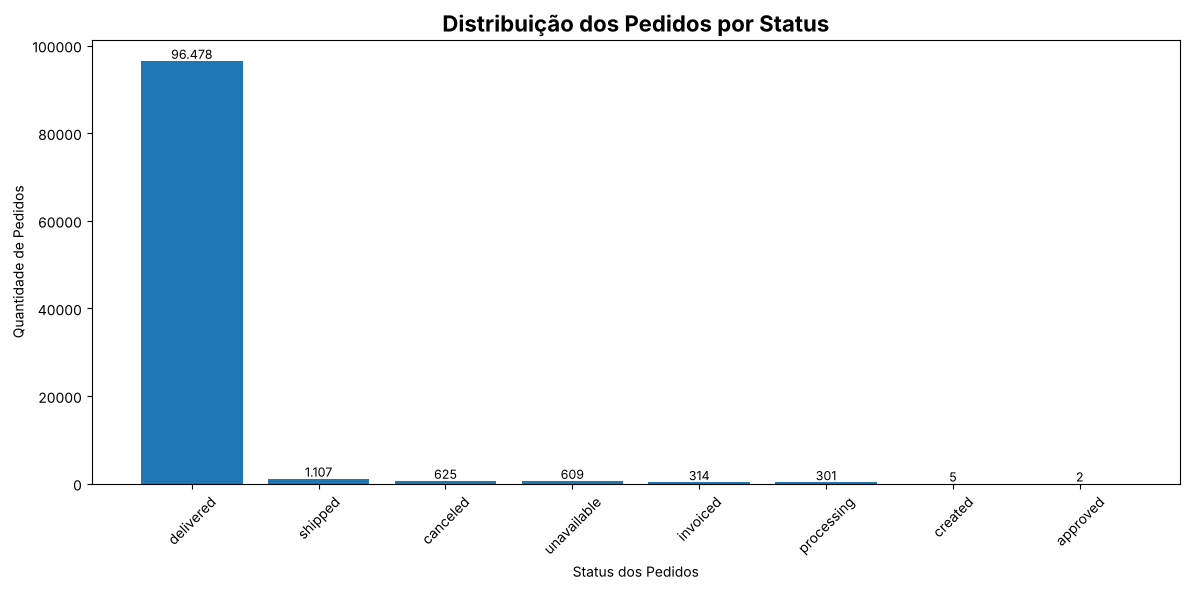

In [32]:
#Visualização dos pedidos pelo Status 

plt.figure(figsize=(12,6))

barras = plt.bar(
    status_pedidos["Status"],
    status_pedidos["Quantidade"]
)

plt.title(
    "Distribuição dos Pedidos por Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Status dos Pedidos")
plt.ylabel("Quantidade de Pedidos")

plt.xticks(rotation=45)

# Exibir valores acima das barras
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 500,
        f"{int(altura):,}".replace(",", "."),
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

####  Análise do Gráfico

Observa-se que a grande maioria dos pedidos encontra-se com o status **"Delivered"**, indicando uma elevada taxa de conclusão das vendas.

Os demais status, como **Shipped**, **Canceled**, **Unavailable** e **Processing**, representam uma parcela significativamente menor dos pedidos, sugerindo que o processo operacional da plataforma apresenta boa eficiência.

Essa distribuição indica que a maior parte das compras é concluída com sucesso, refletindo positivamente na experiência do cliente.

####  Impacto para o Negócio

Acompanhar a distribuição dos pedidos por status permite monitorar a eficiência da operação logística, identificar possíveis gargalos no processo de entrega e acompanhar indicadores relacionados à satisfação do cliente.

####  Conclusão

A operação do e-commerce demonstra elevado índice de pedidos entregues com sucesso, indicando estabilidade operacional e eficiência no fluxo logístico.

Os pedidos cancelados ou indisponíveis representam uma pequena parcela do total e poderão ser investigados em análises futuras para identificar oportunidades de melhoria.

### 4.2 Análise 2 — Faturamento e KPIs


In [33]:
pagamentos.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [34]:
pagamentos.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [35]:
#Faturamento Total

faturamento_total = pagamentos["payment_value"].sum()

print(
    f"Faturamento Total: R$ "
    f"{faturamento_total:,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
)

Faturamento Total: R$ 16.008.872,12


In [36]:
# Quantidade de pedidos
total_pedidos = pagamentos["order_id"].nunique()

print(f"Quantidade de Pedidos: {total_pedidos:,}".replace(",", "."))

Quantidade de Pedidos: 99.440


In [37]:
#Ticket médio por pedido

ticket_medio = faturamento_total / total_pedidos

print(
    f"Ticket Médio: R$ "
    f"{ticket_medio:,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
)

Ticket Médio: R$ 160,99


In [38]:
# RESUMO DOS PRINCIPAIS KPIs

print("=" * 45)
print("        RESUMO DOS PRINCIPAIS KPIs")
print("=" * 45)

print(
    f"Faturamento Total : R$ "
    f"{faturamento_total:,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
)

print(
    f"Total de Pedidos  : "
    f"{total_pedidos:,}".replace(",", ".")
)

print(
    f"Ticket Médio      : R$ "
    f"{ticket_medio:,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
)

print("=" * 45)

        RESUMO DOS PRINCIPAIS KPIs
Faturamento Total : R$ 16.008.872,12
Total de Pedidos  : 99.440
Ticket Médio      : R$ 160,99


#### Análise dos principais KPI`s

Os indicadores financeiros permitem avaliar o volume de negócios movimentado pelo e-commerce.

O faturamento total representa o valor registrado nas transações, enquanto o ticket médio demonstra quanto cada pedido movimentou, em média.

A análise conjunta desses indicadores fornece uma visão inicial do desempenho comercial da plataforma.

#### Análise dos Indicadores

Durante o período analisado, foram registrados aproximadamente **R$ 16 milhões em pagamentos**, distribuídos entre **99.440 pedidos com pagamento registrado** (a base tem 99.441 pedidos; 1 pedido não possui registro de pagamento).

O **ticket médio foi de R$ 160,99 por pedido**, indicando o valor médio movimentado em cada compra realizada na plataforma.

Esses indicadores fornecem uma visão geral do desempenho financeiro do e-commerce e servirão como base para análises mais detalhadas sobre comportamento de compra, formas de pagamento e evolução das vendas.

#### Conclusão

Os resultados demonstram um volume expressivo de transações na plataforma, com aproximadamente **R$ 16 milhões movimentados** e ticket médio de **R$ 160,99**.

Nas próximas análises, esses indicadores serão segmentados para identificar quais formas de pagamento, categorias, períodos e regiões possuem maior participação nos resultados.

#### Impacto para o Negócio

O acompanhamento do valor total dos pagamentos, volume de pedidos e ticket médio permite avaliar o desempenho comercial da operação e identificar oportunidades de crescimento.

O aumento do ticket médio, por exemplo, pode ser trabalhado por meio de estratégias como venda cruzada, recomendações de produtos e campanhas voltadas ao aumento do valor por pedido.

#### Distribuição por Forma de Pagamento

 Objetivo

Identificar quais meios de pagamento são mais utilizados pelos clientes e compreender sua participação nas transações realizadas na plataforma.

In [39]:
pagamentos["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [40]:
# Formas de Pagamento 

formas_pagamento = (
    pagamentos["payment_type"]
    .value_counts()
    .reset_index()
)

formas_pagamento.columns = ["Forma de Pagamento", "Quantidade"]

formas_pagamento

,Forma de Pagamento,Quantidade
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


In [41]:
# Percentual Formas de Pagamento 

formas_pagamento["Percentual"] = (
    formas_pagamento["Quantidade"]
    / formas_pagamento["Quantidade"].sum()
    * 100
)


formas_pagamento["Percentual"] = formas_pagamento["Percentual"].round(2)

formas_pagamento

,Forma de Pagamento,Quantidade,Percentual
0,credit_card,76795,73.92
1,boleto,19784,19.04
2,voucher,5775,5.56
3,debit_card,1529,1.47
4,not_defined,3,0.00


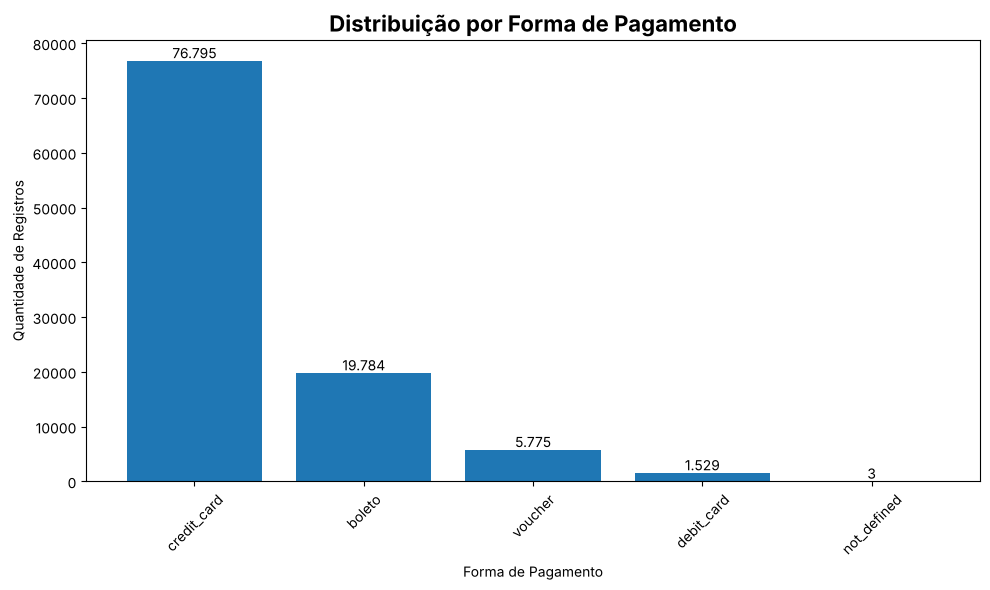

In [42]:
plt.figure(figsize=(10,6))

barras = plt.bar(
    formas_pagamento["Forma de Pagamento"],
    formas_pagamento["Quantidade"]
)

plt.title(
    "Distribuição por Forma de Pagamento",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Forma de Pagamento")
plt.ylabel("Quantidade de Registros")

plt.xticks(rotation=45)

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 500,
        f"{int(altura):,}".replace(",", "."),
        ha="center"
    )

plt.tight_layout()
plt.show()

#### Análise do Gráfico

A análise das formas de pagamento demonstra uma forte preferência dos clientes pelo **cartão de crédito**, que concentra a maior parte dos registros de pagamento da plataforma.

O **boleto** aparece como a segunda forma mais utilizada, enquanto **voucher** e **cartão de débito** apresentam participação significativamente menor.

Esse comportamento indica que o cartão de crédito possui papel relevante no processo de compra dos clientes, possivelmente devido à facilidade de pagamento e à possibilidade de parcelamento.

####  Impacto para o Negócio

A predominância do cartão de crédito demonstra a importância desse meio de pagamento para a operação do e-commerce.

Compreender essa distribuição pode apoiar decisões relacionadas às condições de pagamento, estratégias de parcelamento, negociação de taxas com adquirentes e desenvolvimento de campanhas comerciais.

Também é importante manter alternativas como boleto e cartão de débito para atender diferentes perfis de consumidores.

####  Conclusão

O cartão de crédito é o principal meio de pagamento utilizado na plataforma, seguido pelo boleto.

A concentração das transações nessa modalidade reforça a importância de analisar também o comportamento de parcelamento dos clientes e sua relação com o valor das compras.

### 4.3 Análise 3 — Comportamento de Parcelamento

####  Objetivo

Analisar o comportamento de parcelamento das compras realizadas na plataforma, identificando a quantidade de parcelas mais utilizada pelos clientes e sua possível relação com o comportamento de compra.

In [43]:
parcelamentos = (
    pagamentos["payment_installments"]
    .value_counts()
    .sort_index()
    .reset_index()
)

parcelamentos.columns = ["Parcelas", "Quantidade"]

parcelamentos

,Parcelas,Quantidade
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


In [44]:
pagamentos[
    pagamentos["payment_installments"] == 0
][
    ["payment_type", "payment_installments", "payment_value"]
]

,payment_type,payment_installments,payment_value
46982,credit_card,0,58.69
79014,credit_card,0,129.94


####  Investigação de Inconsistências

Durante a análise da variável `payment_installments`, foram identificados **2 registros de cartão de crédito com valor igual a 0 parcelas**.

Como compras realizadas por cartão de crédito devem possuir pelo menos uma parcela, esses registros foram considerados uma inconsistência na base.

Por representarem uma quantidade pouco significativa em relação ao volume total de pagamentos, os registros serão ajustados de **0 para 1 parcela**, preservando as transações na análise.

In [45]:
pagamentos.loc[
    pagamentos["payment_installments"] == 0,
    "payment_installments"
] = 1

In [46]:
pagamentos["payment_installments"].value_counts().sort_index()

payment_installments
1     52548
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [47]:
parcelamentos = (
    pagamentos["payment_installments"]
    .value_counts()
    .sort_index()
    .reset_index()
)

parcelamentos.columns = ["Parcelas", "Quantidade"]

parcelamentos

,Parcelas,Quantidade
0,1,52548
1,2,12413
2,3,10461
3,4,7098
4,5,5239
5,6,3920
6,7,1626
7,8,4268
8,9,644
9,10,5328


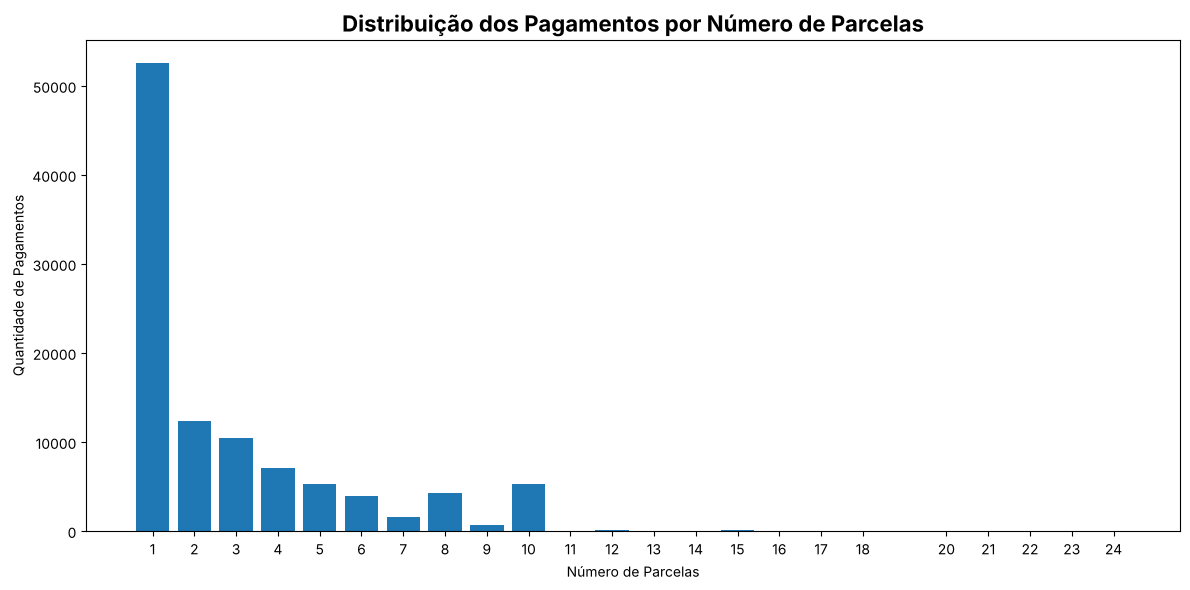

In [48]:
plt.figure(figsize=(12,6))

barras = plt.bar(
    parcelamentos["Parcelas"],
    parcelamentos["Quantidade"]
)

plt.title(
    "Distribuição dos Pagamentos por Número de Parcelas",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Número de Parcelas")
plt.ylabel("Quantidade de Pagamentos")

plt.xticks(parcelamentos["Parcelas"])

plt.tight_layout()
plt.show()

#### Análise por Faixa de Parcelamento

#### Objetivo

Agrupar as transações por faixas de parcelamento para compreender o comportamento de pagamento dos clientes e identificar a concentração das compras entre pagamentos em 1x, parcelamentos curtos, médios e longos.

In [49]:
faixas_parcelamento = pd.cut(
    pagamentos["payment_installments"],
    bins=[0, 1, 5, 10, float("inf")],
    labels=["1x", "2x a 5x", "6x a 10x", "Acima de 10x"]
)

resumo_parcelamento = (
    faixas_parcelamento
    .value_counts()
    .sort_index()
    .reset_index()
)

resumo_parcelamento.columns = ["Faixa de Parcelamento", "Quantidade"]

resumo_parcelamento

,Faixa de Parcelamento,Quantidade
0,1x,52548
1,2x a 5x,35211
2,6x a 10x,15786
3,Acima de 10x,341


In [50]:
resumo_parcelamento["Percentual"] = (
    resumo_parcelamento["Quantidade"]
    / resumo_parcelamento["Quantidade"].sum()
    * 100
)

resumo_parcelamento["Percentual"] = (
    resumo_parcelamento["Percentual"].round(2)
)

resumo_parcelamento

,Faixa de Parcelamento,Quantidade,Percentual
0,1x,52548,50.58
1,2x a 5x,35211,33.89
2,6x a 10x,15786,15.20
3,Acima de 10x,341,0.33


#### Análise dos Resultados

A análise das faixas de parcelamento mostra uma forte concentração das transações em poucas parcelas.

- **50,58%** dos pagamentos foram realizados em **1x**, representando a principal forma de pagamento.
- **33,89%** ocorreram entre **2x e 5x**.
- **15,20%** ficaram entre **6x e 10x**.
- Apenas **0,33%** utilizaram mais de **10 parcelas**.

Somadas, as faixas de **1x a 5x representam 84,47% dos registros de pagamento**, indicando uma preferência dos clientes por pagamentos à vista ou parcelamentos de curto prazo.

#### Relação entre Parcelamento e Valor da Compra

#### Objetivo

Analisar se o valor médio das transações aumenta conforme cresce o número de parcelas utilizadas pelos clientes.

### 4.3.1 Ticket Médio por Número de Parcelas




#### Objetivo

Analisar a relação entre o número de parcelas e o valor médio das transações, buscando identificar se compras de maior valor apresentam maior tendência de parcelamento.

In [51]:
ticket_por_parcela = (
    pagamentos
    .groupby("payment_installments")["payment_value"]
    .agg(["count", "mean"])
    .reset_index()
)

ticket_por_parcela.columns = [
    "Parcelas",
    "Quantidade",
    "Ticket Médio"
]

ticket_por_parcela["Ticket Médio"] = (
    ticket_por_parcela["Ticket Médio"].round(2)
)

ticket_por_parcela

,Parcelas,Quantidade,Ticket Médio
0,1,52548,112.42
1,2,12413,127.23
2,3,10461,142.54
3,4,7098,163.98
4,5,5239,183.47
5,6,3920,209.85
6,7,1626,187.67
7,8,4268,307.74
8,9,644,203.44
9,10,5328,415.09


#### Observação sobre Inconsistências

Durante a análise foram identificados registros com `payment_installments = 0`.

Como esse valor não representa uma condição válida de parcelamento, esses registros serão desconsiderados especificamente nas análises relacionadas ao comportamento de parcelamento, preservando a base original.

In [52]:
pagamentos_parcelamento = pagamentos[
    pagamentos["payment_installments"] > 0
].copy()

In [53]:
pagamentos_parcelamento["payment_installments"].min()

np.int64(1)

In [54]:
ticket_por_parcela = (
    pagamentos_parcelamento
    .groupby("payment_installments")["payment_value"]
    .agg(["count", "mean"])
    .reset_index()
)

ticket_por_parcela.columns = [
    "Parcelas",
    "Quantidade",
    "Ticket Médio"
]

ticket_por_parcela["Ticket Médio"] = (
    ticket_por_parcela["Ticket Médio"].round(2)
)

ticket_por_parcela

,Parcelas,Quantidade,Ticket Médio
0,1,52548,112.42
1,2,12413,127.23
2,3,10461,142.54
3,4,7098,163.98
4,5,5239,183.47
5,6,3920,209.85
6,7,1626,187.67
7,8,4268,307.74
8,9,644,203.44
9,10,5328,415.09


#### Visualização do Ticket Médio por Número de Parcelas

O gráfico a seguir permite visualizar a relação entre a quantidade de parcelas e o ticket médio das transações, facilitando a identificação de padrões no comportamento de compra dos clientes.

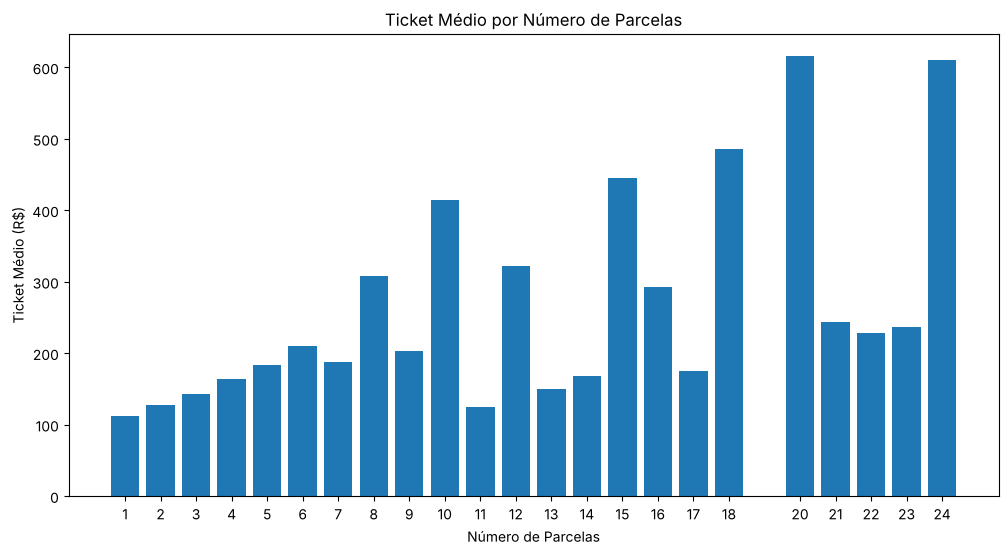

In [55]:
plt.figure(figsize=(12, 6))

plt.bar(
    ticket_por_parcela["Parcelas"],
    ticket_por_parcela["Ticket Médio"]
)

plt.title("Ticket Médio por Número de Parcelas")
plt.xlabel("Número de Parcelas")
plt.ylabel("Ticket Médio (R$)")

plt.xticks(ticket_por_parcela["Parcelas"])

plt.show()

In [56]:
ticket_ate_10x = ticket_por_parcela[
    ticket_por_parcela["Parcelas"] <= 10
]

ticket_ate_10x

,Parcelas,Quantidade,Ticket Médio
0,1,52548,112.42
1,2,12413,127.23
2,3,10461,142.54
3,4,7098,163.98
4,5,5239,183.47
5,6,3920,209.85
6,7,1626,187.67
7,8,4268,307.74
8,9,644,203.44
9,10,5328,415.09


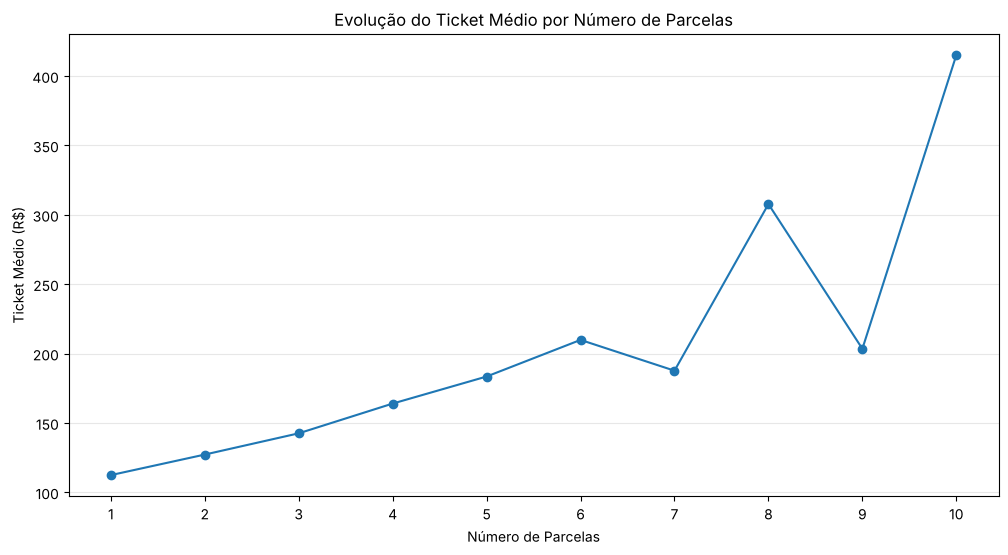

In [57]:
plt.figure(figsize=(12, 6))

plt.plot(
    ticket_ate_10x["Parcelas"],
    ticket_ate_10x["Ticket Médio"],
    marker="o"
)

plt.title("Evolução do Ticket Médio por Número de Parcelas")
plt.xlabel("Número de Parcelas")
plt.ylabel("Ticket Médio (R$)")

plt.xticks(ticket_ate_10x["Parcelas"])
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Análise do Gráfico

A análise indica uma tendência de aumento do ticket médio conforme cresce o número de parcelas utilizadas nas transações.

Os pagamentos realizados em **1x apresentam ticket médio de R$ 112,42**, enquanto transações parceladas em **5x alcançam R$ 183,47**. Em parcelamentos maiores, essa diferença se torna ainda mais evidente, com ticket médio de **R$ 307,74 em 8x** e **R$ 415,09 em 10x**.

Apesar da tendência geral de crescimento, o comportamento não é totalmente linear, apresentando algumas oscilações entre determinadas quantidades de parcelas.

Os resultados sugerem que o parcelamento é utilizado com maior intensidade em transações de maior valor.

#### Impacto para o Negócio

O parcelamento pode atuar como um importante facilitador para compras de maior valor.

A possibilidade de dividir o pagamento reduz o impacto financeiro imediato para o consumidor e pode contribuir para a realização de transações com tickets mais elevados.

Esse comportamento pode ser utilizado pelo negócio para:

- incentivar o parcelamento em produtos de maior valor;
- desenvolver campanhas comerciais associadas às condições de pagamento;
- avaliar oportunidades para aumento do ticket médio;
- entender melhor a relação entre preço, parcelamento e decisão de compra.

Ao mesmo tempo, condições de parcelamento devem ser avaliadas considerando custos financeiros e possíveis impactos sobre a rentabilidade.

#### Conclusão

Os dados mostram que pagamentos em **1x representam a maior parte das transações**, correspondendo a aproximadamente **50,58% dos registros analisados**.

Quando consideradas as faixas de parcelamento, **84,47% dos pagamentos estão concentrados entre 1x e 5x**, demonstrando preferência por pagamentos à vista ou parcelamentos de curto prazo.

Entretanto, a análise do ticket médio mostra que transações com maior número de parcelas tendem a apresentar valores médios superiores.

Portanto, embora parcelamentos longos sejam menos frequentes, eles estão associados a transações de maior valor, indicando que o parcelamento pode desempenhar um papel relevante na viabilização de compras com tickets mais elevados.

### 4.4 Análise 4 — Evolução das Vendas ao Longo do Tempo

#### Objetivo

Analisar a evolução do volume de pedidos e do faturamento ao longo do tempo, identificando períodos de crescimento, queda e possíveis padrões de sazonalidade.

A análise permitirá compreender o comportamento das vendas da plataforma ao longo dos meses e identificar períodos relevantes para o desempenho do negócio.

In [58]:
pedidos[
    ["order_id", "order_status", "order_purchase_timestamp"]
].head()

,order_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39


In [59]:
pagamentos[
    ["order_id", "payment_value"]
].head()

,order_id,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,65.71
3,ba78997921bbcdc1373bb41e913ab953,107.78
4,42fdf880ba16b47b59251dd489d4441a,128.45


#### Preparação dos Dados

Para realizar a análise temporal, os registros de pagamento serão consolidados por pedido utilizando o `order_id`.

Essa etapa evita duplicações durante a integração das tabelas e permite associar corretamente o valor total pago à data de realização de cada pedido.

In [60]:
pagamentos_por_pedido = (
    pagamentos
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

pagamentos_por_pedido.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [61]:
pagamentos_por_pedido["order_id"].duplicated().sum()

np.int64(0)

In [62]:
vendas = pedidos.merge(
    pagamentos_por_pedido,
    on="order_id",
    how="left"
)

vendas.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62


In [63]:
print("Linhas em pedidos:", len(pedidos))
print("Linhas em vendas:", len(vendas))

print(
    "Pedidos sem pagamento:",
    vendas["payment_value"].isnull().sum()
)

Linhas em pedidos: 99441
Linhas em vendas: 99441
Pedidos sem pagamento: 1


In [64]:
vendas["order_purchase_timestamp"].dtype

vendas["order_purchase_timestamp"] = pd.to_datetime(
    vendas["order_purchase_timestamp"]
)

vendas["order_purchase_timestamp"].dtype

dtype('<M8[us]')

In [65]:
vendas["ano"] = vendas["order_purchase_timestamp"].dt.year
vendas["mes"] = vendas["order_purchase_timestamp"].dt.month

vendas[
    ["order_purchase_timestamp", "ano", "mes"]
].head()

vendas["ano_mes"] = (
    vendas["order_purchase_timestamp"]
    .dt.to_period("M")
)

vendas[
    ["order_purchase_timestamp", "ano_mes"]
].head()

,order_purchase_timestamp,ano_mes
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [66]:
print(
    "Primeira compra:",
    vendas["order_purchase_timestamp"].min()
)

print(
    "Última compra:",
    vendas["order_purchase_timestamp"].max()
)

Primeira compra: 2016-09-04 21:15:19
Última compra: 2018-10-17 17:30:18


#### Preparação da Análise Temporal

A coluna `order_purchase_timestamp` foi convertida para o formato de data e utilizada para criar as variáveis de ano, mês e período mensal.

Essa preparação permitirá analisar a evolução histórica dos pedidos e do faturamento da plataforma ao longo do período disponível na base de dados.

### 4.4.1 Evolução Mensal das Vendas


#### Objetivo

Analisar a evolução do volume de pedidos e do faturamento ao longo do tempo, identificando tendências, períodos de crescimento, quedas e possíveis comportamentos sazonais.

In [67]:
vendas_mensais = (
    vendas
    .groupby("ano_mes")
    .agg(
        Quantidade_Pedidos=("order_id", "nunique"),
        Faturamento=("payment_value", "sum")
    )
    .reset_index()
)

vendas_mensais.head(10)

,ano_mes,Quantidade_Pedidos,Faturamento
0,2016-09,4,252.24
1,2016-10,324,"59,090.48"
2,2016-12,1,19.62
3,2017-01,800,"138,488.04"
4,2017-02,1780,"291,908.01"
5,2017-03,2682,"449,863.60"
6,2017-04,2404,"417,788.03"
7,2017-05,3700,"592,918.82"
8,2017-06,3245,"511,276.38"
9,2017-07,4026,"592,382.92"


In [68]:
vendas_mensais

,ano_mes,Quantidade_Pedidos,Faturamento
0,2016-09,4,252.24
1,2016-10,324,"59,090.48"
2,2016-12,1,19.62
3,2017-01,800,"138,488.04"
4,2017-02,1780,"291,908.01"
5,2017-03,2682,"449,863.60"
6,2017-04,2404,"417,788.03"
7,2017-05,3700,"592,918.82"
8,2017-06,3245,"511,276.38"
9,2017-07,4026,"592,382.92"


#### Conclusão da Cobertura Temporal

A análise da série histórica identificou períodos com baixa representatividade no início e no final da base de dados.

Os registros de 2016 apresentam volumes muito reduzidos e descontínuos, indicando uma fase inicial com baixa cobertura de dados. Da mesma forma, setembro e outubro de 2018 apresentam queda abrupta no número de pedidos em comparação aos meses anteriores, sugerindo períodos incompletos.

Para evitar distorções na análise da evolução das vendas, será considerado como período principal de análise o intervalo entre **janeiro de 2017 e agosto de 2018**.

Os registros fora desse intervalo serão preservados na base original, sendo excluídos apenas da análise temporal.

In [69]:
vendas_mensais_analise = vendas_mensais[
    (vendas_mensais["ano_mes"] >= "2017-01") &
    (vendas_mensais["ano_mes"] <= "2018-08")
].copy()

vendas_mensais_analise

,ano_mes,Quantidade_Pedidos,Faturamento
3,2017-01,800,"138,488.04"
4,2017-02,1780,"291,908.01"
5,2017-03,2682,"449,863.60"
6,2017-04,2404,"417,788.03"
7,2017-05,3700,"592,918.82"
8,2017-06,3245,"511,276.38"
9,2017-07,4026,"592,382.92"
10,2017-08,4331,"674,396.32"
11,2017-09,4285,"727,762.45"
12,2017-10,4631,"779,677.88"


### 4.4.2 Evolução do Número de Pedidos

#### Objetivo

Analisar a evolução mensal da quantidade de pedidos realizados na plataforma, identificando períodos de crescimento, queda e possíveis variações sazonais.

In [70]:
vendas_mensais_analise["ano_mes_texto"] = (
    vendas_mensais_analise["ano_mes"].astype(str)
)

In [71]:
vendas_mensais_analise[
    ["ano_mes", "ano_mes_texto"]
].head()

,ano_mes,ano_mes_texto
3,2017-01,2017-01
4,2017-02,2017-02
5,2017-03,2017-03
6,2017-04,2017-04
7,2017-05,2017-05


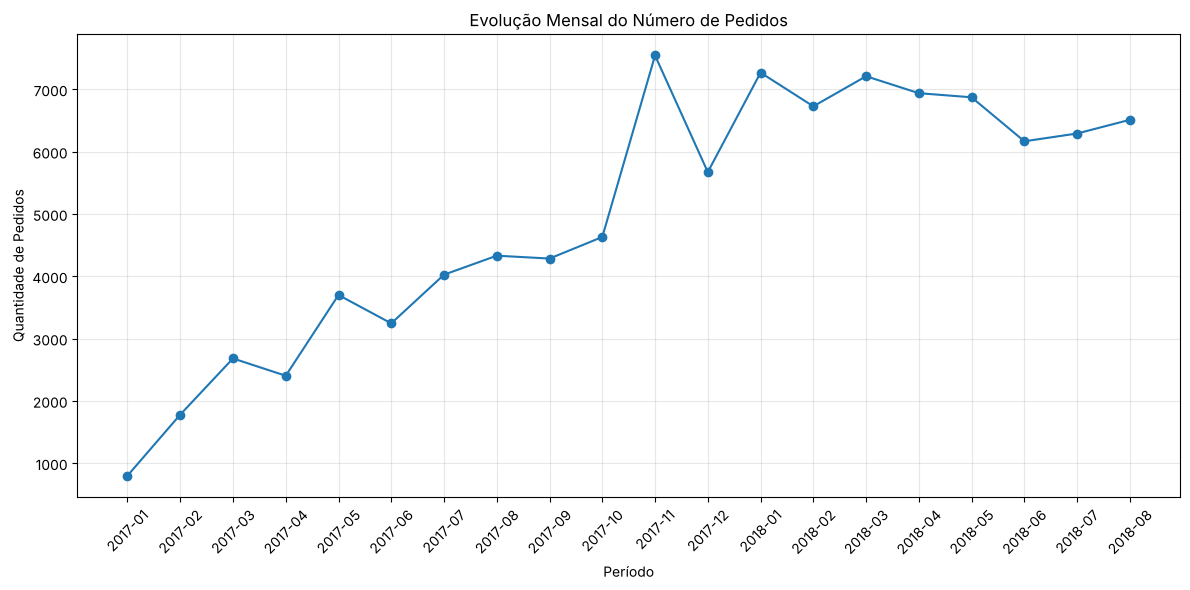

In [72]:
plt.figure(figsize=(12, 6))

plt.plot(
    vendas_mensais_analise["ano_mes_texto"],
    vendas_mensais_analise["Quantidade_Pedidos"],
    marker="o"
)

plt.title("Evolução Mensal do Número de Pedidos")
plt.xlabel("Período")
plt.ylabel("Quantidade de Pedidos")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### Análise do Gráfico

O gráfico evidencia um crescimento significativo no volume mensal de pedidos ao longo de 2017.

O número de pedidos passou de aproximadamente **800 em janeiro de 2017** para patamares superiores a **4 mil pedidos mensais** no segundo semestre do mesmo ano.

Destaca-se **novembro de 2017**, com **7.544 pedidos**, representando um dos maiores volumes do período analisado. Esse comportamento pode estar relacionado a fatores sazonais e períodos promocionais típicos do final do ano.

Em 2018, observa-se maior estabilidade no volume de pedidos, que permaneceu predominantemente acima de **6 mil pedidos mensais**, indicando uma consolidação do volume de vendas em um patamar superior ao observado no início de 2017.

#### Impacto para o Negócio

O crescimento do número de pedidos demonstra uma expansão relevante da atividade comercial da plataforma.

O aumento da demanda exige maior capacidade operacional em áreas como processamento de pedidos, logística, atendimento ao cliente e relacionamento com vendedores.

Além disso, a identificação de períodos de maior demanda permite antecipar necessidades operacionais e apoiar o planejamento de campanhas comerciais e ações promocionais.

#### Conclusão

A análise demonstra uma evolução significativa no volume de pedidos entre janeiro de 2017 e agosto de 2018.

Após um período de forte crescimento durante 2017, a operação passou a apresentar volumes mensais mais elevados e relativamente estáveis em 2018, indicando amadurecimento da atividade comercial da plataforma.

### 4.4.3 Evolução do Faturamento


#### Objetivo

Analisar a evolução mensal do faturamento da plataforma, identificando tendências de crescimento, períodos de maior receita e possíveis oscilações ao longo do tempo.

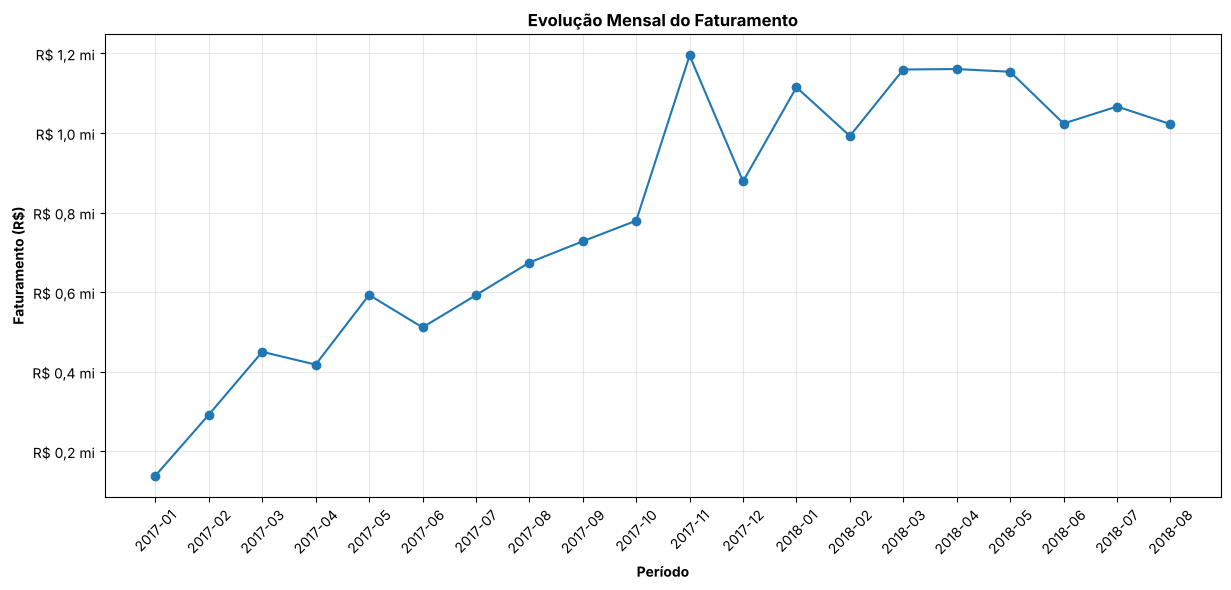

In [73]:
# Evolução Mensal do Faturamento

import matplotlib.pyplot as plt

# Converter o período para texto para exibição no eixo X
vendas_mensais_analise["ano_mes_texto"] = (
    vendas_mensais_analise["ano_mes"].astype(str)
)

# Criar o gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    vendas_mensais_analise["ano_mes_texto"],
    vendas_mensais_analise["Faturamento"],
    marker="o"
)

# Título e eixos
plt.title(
    "Evolução Mensal do Faturamento",
    fontweight="bold"
)

plt.xlabel(
    "Período",
    fontweight="bold"
)

plt.ylabel(
    "Faturamento (R$)",
    fontweight="bold"
)

# Formatação
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

# Eixo Y em milhões de reais (evita a notação científica 1e6)
from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"R$ {valor / 1e6:.1f} mi".replace(".", ","))
)

# Salvar imagem para o README
plt.savefig(
    "../imagens/faturamento_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibir gráfico
plt.show()

#### Análise do Gráfico

O faturamento mensal apresenta uma trajetória de crescimento expressiva ao longo de 2017, acompanhando o aumento observado no volume de pedidos.

Destaca-se novembro de 2017, quando o faturamento atingiu aproximadamente **R$ 1,19 milhão**, representando um dos maiores resultados do período analisado.

Durante 2018, o faturamento passou a se manter predominantemente próximo ou acima de **R$ 1 milhão por mês**, demonstrando maior estabilidade em comparação ao crescimento acelerado observado durante 2017.

Apesar dessa estabilidade, são observadas oscilações mensais, indicando que o faturamento não depende apenas da quantidade de pedidos, mas também do valor médio das transações.

#### Impacto para o Negócio

A evolução do faturamento demonstra crescimento relevante da operação e maior capacidade de geração de receita ao longo do período analisado.

A identificação de períodos de maior faturamento pode apoiar o planejamento comercial, a definição de campanhas promocionais e a preparação da operação para períodos de maior demanda.

Além disso, acompanhar conjuntamente faturamento, quantidade de pedidos e ticket médio permite compreender se o crescimento da receita está sendo impulsionado pelo aumento do volume de vendas, pelo valor das compras ou pela combinação dos dois fatores.

### 4.4.4 Relação entre Pedidos, Faturamento e Ticket Médio


#### Objetivo

Analisar conjuntamente a evolução do número de pedidos, do faturamento e do ticket médio, buscando compreender quais fatores contribuíram para o crescimento da receita ao longo do período.

In [74]:
vendas_mensais_analise["Ticket_Medio"] = (
    vendas_mensais_analise["Faturamento"]
    / vendas_mensais_analise["Quantidade_Pedidos"]
)

vendas_mensais_analise["Ticket_Medio"] = (
    vendas_mensais_analise["Ticket_Medio"].round(2)
)

vendas_mensais_analise[
    [
        "ano_mes",
        "Quantidade_Pedidos",
        "Faturamento",
        "Ticket_Medio"
    ]
]

,ano_mes,Quantidade_Pedidos,Faturamento,Ticket_Medio
3,2017-01,800,"138,488.04",173.11
4,2017-02,1780,"291,908.01",163.99
5,2017-03,2682,"449,863.60",167.73
6,2017-04,2404,"417,788.03",173.79
7,2017-05,3700,"592,918.82",160.25
8,2017-06,3245,"511,276.38",157.56
9,2017-07,4026,"592,382.92",147.14
10,2017-08,4331,"674,396.32",155.71
11,2017-09,4285,"727,762.45",169.84
12,2017-10,4631,"779,677.88",168.36


#### Visualização do Ticket Médio

O gráfico a seguir apresenta a evolução do ticket médio mensal, permitindo identificar variações no valor médio gasto pelos clientes em cada pedido ao longo do período analisado.

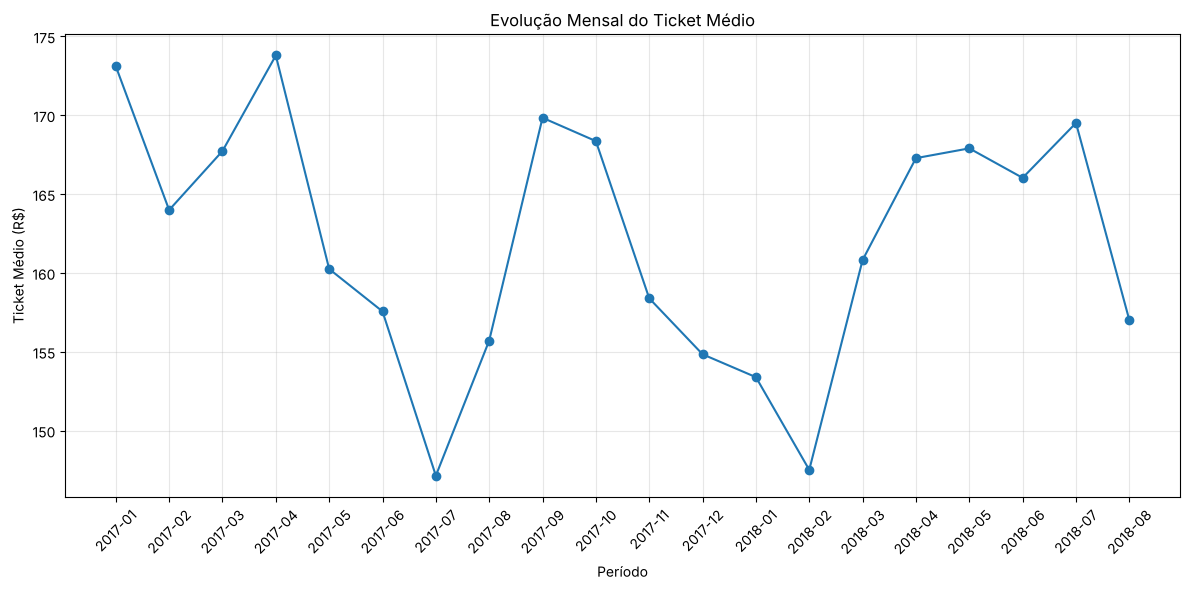

In [75]:
plt.figure(figsize=(12, 6))

plt.plot(
    vendas_mensais_analise["ano_mes_texto"],
    vendas_mensais_analise["Ticket_Medio"],
    marker="o"
)

plt.title("Evolução Mensal do Ticket Médio")
plt.xlabel("Período")
plt.ylabel("Ticket Médio (R$)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Análise do Gráfico

O ticket médio apresentou oscilações ao longo do período analisado, permanecendo predominantemente entre aproximadamente R$ 150 e R$ 170.

Foram observados períodos de queda, como em julho de 2017 e fevereiro de 2018, seguidos por recuperações nos meses posteriores.

Apesar dessas variações, não é possível identificar uma tendência contínua de crescimento do ticket médio, indicando relativa estabilidade no valor médio das compras.

#### Impacto para o Negócio

A relativa estabilidade do ticket médio, combinada ao crescimento observado no faturamento e na quantidade de pedidos, indica que a expansão da receita foi impulsionada principalmente pelo aumento do volume de vendas.

Esse comportamento demonstra crescimento da operação e maior geração de transações, mas também revela uma oportunidade para estratégias voltadas ao aumento do valor médio dos pedidos, como recomendações de produtos, vendas combinadas e incentivos para compras de maior valor.

#### Conclusão

A análise conjunta dos indicadores mostra que o crescimento do faturamento ocorreu principalmente em função do aumento da quantidade de pedidos, enquanto o ticket médio permaneceu relativamente estável.

Isso indica que a plataforma conseguiu ampliar seu volume de vendas ao longo do período analisado, existindo ainda potencial para crescimento adicional por meio de estratégias que aumentem o valor médio gasto por pedido.

## 5. Análise das Categorias de Produtos

Nesta etapa será analisado o desempenho das categorias de produtos presentes na plataforma, buscando identificar quais categorias possuem maior volume de vendas e maior participação no negócio.



#### Objetivo

Identificar as categorias de produtos com maior quantidade de vendas e compreender sua relevância dentro da operação do e-commerce.

In [76]:
print("Colunas da tabela PRODUTOS:")
print(produtos.columns.tolist())

print("\nColunas da tabela ITENS:")
print(itens.columns.tolist())

Colunas da tabela PRODUTOS:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Colunas da tabela ITENS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


### 5.1 Preparação dos Dados

Para analisar o desempenho das categorias, será necessário combinar as informações da tabela de itens dos pedidos com a tabela de produtos.

As duas tabelas possuem a coluna `product_id`, que será utilizada como chave de relacionamento.

Essa combinação permitirá associar cada item vendido à sua respectiva categoria de produto.

In [77]:
itens_produtos = itens.merge(
    produtos[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

itens_produtos.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [78]:
print("Linhas da tabela itens:", len(itens))
print("Linhas após o merge:", len(itens_produtos))

print(
    "Itens sem categoria:",
    itens_produtos["product_category_name"].isnull().sum()
)

Linhas da tabela itens: 112650
Linhas após o merge: 112650
Itens sem categoria: 1603


### 5.2 Ranking das Categorias Mais Vendidas

#### Objetivo

Identificar quais categorias de produtos apresentam o maior volume de itens vendidos na plataforma.

Essa análise permite compreender quais tipos de produtos possuem maior participação nas vendas e maior demanda entre os clientes.

In [79]:
ranking_categorias = (
    itens_produtos["product_category_name"]
    .value_counts()
    .reset_index()
)

ranking_categorias.columns = [
    "Categoria",
    "Quantidade_Vendida"
]

ranking_categorias.head(10)

,Categoria,Quantidade_Vendida
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


In [80]:
print(
    "Quantidade de categorias:",
    ranking_categorias.shape[0]
)

Quantidade de categorias: 73


#### Visualização das Categorias Mais Vendidas

Para facilitar a interpretação dos resultados, serão consideradas as 10 categorias com maior quantidade de itens vendidos.

Essa visualização permite identificar rapidamente quais categorias concentram a maior demanda dentro da plataforma.

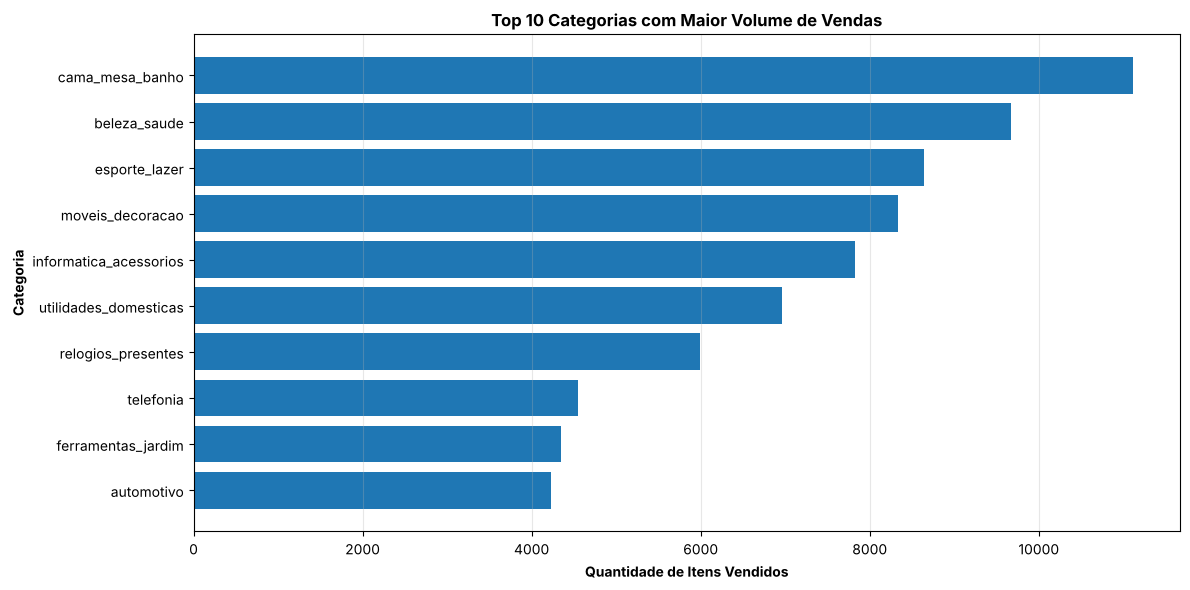

In [81]:
# Top 10 Categorias com Maior Volume de Vendas

# Selecionar as 10 categorias com maior volume de vendas
top10_categorias = ranking_categorias.head(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))

plt.barh(
    top10_categorias["Categoria"],
    top10_categorias["Quantidade_Vendida"]
)

# Título e eixos
plt.title(
    "Top 10 Categorias com Maior Volume de Vendas",
    fontweight="bold"
)

plt.xlabel(
    "Quantidade de Itens Vendidos",
    fontweight="bold"
)

plt.ylabel(
    "Categoria",
    fontweight="bold"
)

# Exibir a categoria com maior volume no topo
plt.gca().invert_yaxis()

# Grade
plt.grid(
    axis="x",
    alpha=0.3
)

# Ajustar o layout
plt.tight_layout()

# Salvar imagem para o README
plt.savefig(
    "../imagens/categorias_mais_vendidas.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibir o gráfico
plt.show()

#### Análise do Gráfico

O ranking demonstra que a categoria `cama_mesa_banho` apresenta o maior volume de itens vendidos, seguida por `beleza_saude`, `esporte_lazer` e `moveis_decoracao`.

Também se destacam categorias como `informatica_acessorios` e `utilidades_domesticas`, indicando uma concentração relevante das vendas em produtos relacionados à casa, cuidados pessoais, lazer e tecnologia.

Apesar da existência de 73 categorias na base, algumas delas apresentam volume de vendas significativamente superior às demais.

#### Impacto para o Negócio

A identificação das categorias com maior volume de vendas permite compreender quais segmentos possuem maior demanda dentro da plataforma.

Essas informações podem apoiar decisões relacionadas à gestão de estoque, campanhas promocionais, relacionamento com vendedores e estratégias comerciais direcionadas às categorias de maior procura.

### 5.3 Faturamento por Categoria

#### Objetivo

Analisar o valor total movimentado por cada categoria de produto e comparar o desempenho financeiro com o volume de itens vendidos.

Essa análise permite verificar se as categorias com maior quantidade de vendas também são responsáveis pelo maior faturamento.

In [82]:
faturamento_categoria = (
    itens_produtos
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

faturamento_categoria.columns = [
    "Categoria",
    "Faturamento"
]

faturamento_categoria["Faturamento"] = (
    faturamento_categoria["Faturamento"].round(2)
)

faturamento_categoria.head(10)

,Categoria,Faturamento
0,beleza_saude,"1,258,681.34"
1,relogios_presentes,"1,205,005.68"
2,cama_mesa_banho,"1,036,988.68"
3,esporte_lazer,"988,048.97"
4,informatica_acessorios,"911,954.32"
5,moveis_decoracao,"729,762.49"
6,cool_stuff,"635,290.85"
7,utilidades_domesticas,"632,248.66"
8,automotivo,"592,720.11"
9,ferramentas_jardim,"485,256.46"


#### Visualização do Faturamento por Categoria

O gráfico apresenta as 10 categorias responsáveis pelos maiores valores de vendas, permitindo comparar o desempenho financeiro das diferentes categorias de produtos.

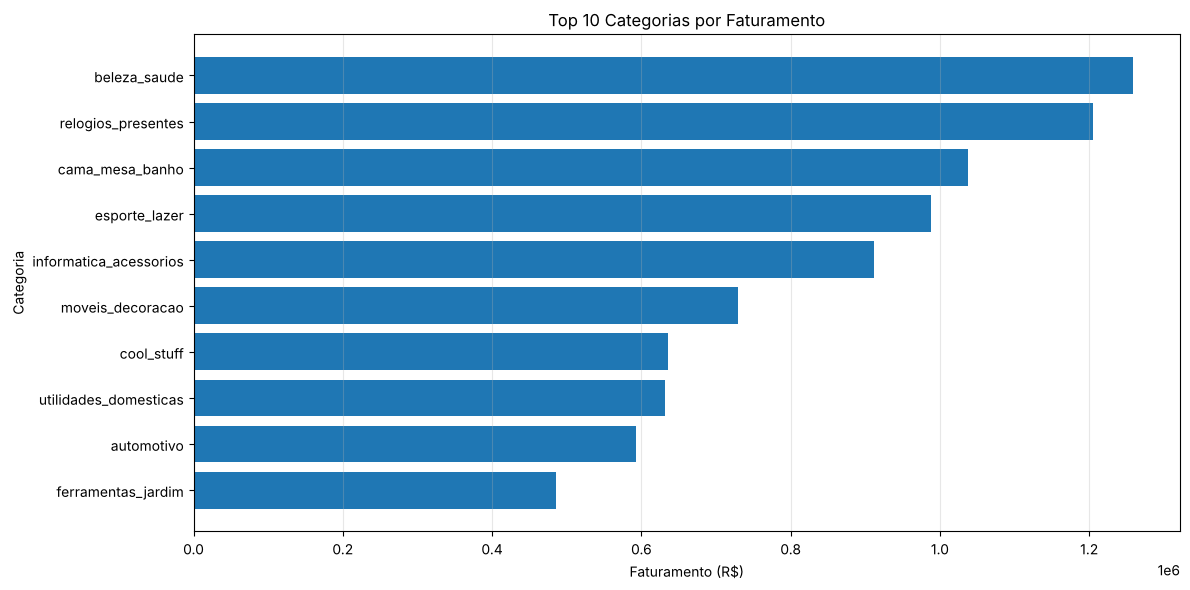

In [83]:
top10_faturamento = faturamento_categoria.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_faturamento["Categoria"],
    top10_faturamento["Faturamento"]
)

plt.title("Top 10 Categorias por Faturamento")
plt.xlabel("Faturamento (R$)")
plt.ylabel("Categoria")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

#### Análise do Gráfico

A categoria `beleza_saude` apresenta o maior faturamento entre as categorias analisadas, movimentando aproximadamente R$ 1,26 milhão.

Em seguida aparece `relogios_presentes`, com aproximadamente R$ 1,21 milhão, mesmo não estando entre as primeiras posições em quantidade de itens vendidos.

A categoria `cama_mesa_banho`, apesar de liderar o ranking em volume de vendas, ocupa a terceira posição em faturamento, com aproximadamente R$ 1,04 milhão.

Os resultados demonstram que um maior volume de itens vendidos não necessariamente representa maior faturamento.

### 5.4 Valor Médio por Item de Cada Categoria

#### Objetivo

Analisar o valor médio dos itens vendidos em cada categoria, buscando compreender como o preço médio dos produtos influencia o faturamento.

Essa análise complementa os rankings de volume de vendas e faturamento, permitindo identificar categorias que apresentam menor quantidade de itens vendidos, mas possuem maior valor médio por produto.


In [84]:
valor_medio_categoria = (
    itens_produtos
    .groupby("product_category_name")["price"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

valor_medio_categoria.columns = [
    "Categoria",
    "Valor_Medio"
]

valor_medio_categoria["Valor_Medio"] = (
    valor_medio_categoria["Valor_Medio"].round(2)
)

valor_medio_categoria.head(10)

,Categoria,Valor_Medio
0,pcs,"1,098.34"
1,portateis_casa_forno_e_cafe,624.29
2,eletrodomesticos_2,476.12
3,agro_industria_e_comercio,342.12
4,instrumentos_musicais,281.62
5,eletroportateis,280.78
6,portateis_cozinha_e_preparadores_de_alimentos,264.57
7,telefonia_fixa,225.69
8,construcao_ferramentas_seguranca,208.99
9,relogios_presentes,201.14


In [85]:
valor_medio_categoria[
    valor_medio_categoria["Categoria"] == "relogios_presentes"
]

,Categoria,Valor_Medio
9,relogios_presentes,201.14


In [86]:
valor_medio_categoria.head(10)

,Categoria,Valor_Medio
0,pcs,"1,098.34"
1,portateis_casa_forno_e_cafe,624.29
2,eletrodomesticos_2,476.12
3,agro_industria_e_comercio,342.12
4,instrumentos_musicais,281.62
5,eletroportateis,280.78
6,portateis_cozinha_e_preparadores_de_alimentos,264.57
7,telefonia_fixa,225.69
8,construcao_ferramentas_seguranca,208.99
9,relogios_presentes,201.14


#### Análise do Valor Médio

A categoria `relogios_presentes` apresenta valor médio por item de aproximadamente **R$ 201,14**, posicionando-se entre as categorias com maior valor médio da plataforma.

Esse resultado ajuda a explicar seu forte desempenho financeiro. Embora a categoria não esteja entre as líderes em quantidade de itens vendidos, ela ocupa a **2ª posição em faturamento**, com aproximadamente **R$ 1,2 milhão**.

Isso indica que o desempenho da categoria é impulsionado não apenas pelo volume de vendas, mas principalmente pelo maior valor dos produtos comercializados.

Em contrapartida, categorias como `cama_mesa_banho` apresentam grande volume de vendas, porém trabalham com produtos de menor valor médio.

Portanto, a análise demonstra que **volume de vendas e faturamento não necessariamente seguem o mesmo comportamento**, sendo o valor médio dos produtos um fator importante para compreender o desempenho financeiro das categorias.

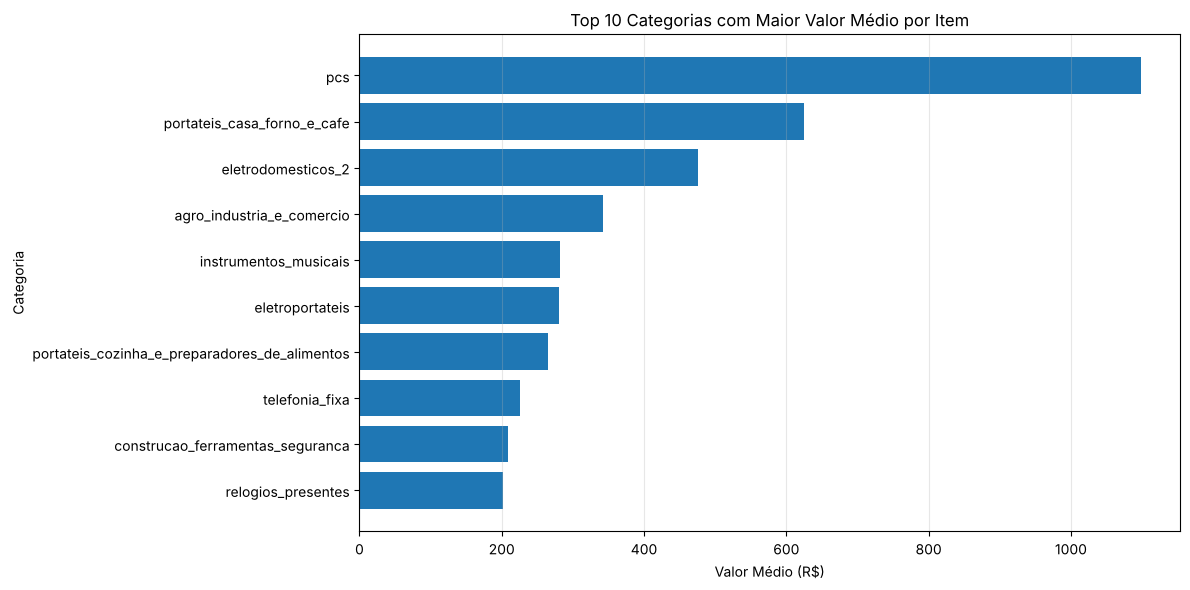

In [87]:
top10_valor_medio = valor_medio_categoria.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_valor_medio["Categoria"],
    top10_valor_medio["Valor_Medio"]
)

plt.title("Top 10 Categorias com Maior Valor Médio por Item")
plt.xlabel("Valor Médio (R$)")
plt.ylabel("Categoria")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Análise do Gráfico

O gráfico evidencia diferenças significativas no valor médio dos produtos entre as categorias.

A categoria `pcs` apresenta o maior valor médio por item, ultrapassando R$ 1.000, ficando consideravelmente acima das demais categorias.

Também se destacam categorias como `portateis_casa_forno_e_cafe`, `eletrodomesticos_2` e `agro_industria_e_comercio`, que possuem produtos com valores médios mais elevados.

Outro destaque é `relogios_presentes`, que aparece entre as 10 categorias com maior valor médio e também ocupa uma posição relevante no ranking de faturamento.

Esses resultados demonstram que categorias com menor volume de vendas podem apresentar forte impacto financeiro quando possuem produtos de maior valor.

### Impacto para o Negócio

A análise das categorias mostra que o desempenho comercial deve ser avaliado considerando diferentes indicadores.

Categorias com grande volume de vendas, como `cama_mesa_banho`, podem ser importantes para geração de tráfego e recorrência de compras.

Por outro lado, categorias como `relogios_presentes` apresentam maior valor médio por item e forte participação no faturamento, podendo contribuir significativamente para a receita mesmo com menor volume de vendas.

Essas informações podem apoiar decisões relacionadas a:

- definição de campanhas promocionais;
- estratégias de estoque;
- priorização de categorias;
- negociação com vendedores;
- estratégias de aumento do ticket médio.

### Conclusão

A análise demonstrou que quantidade vendida, faturamento e valor médio representam perspectivas diferentes sobre o desempenho das categorias.

`cama_mesa_banho` se destaca pelo alto volume de vendas, enquanto `beleza_saude` lidera em faturamento.

Já `relogios_presentes` apresenta uma combinação relevante entre faturamento elevado e maior valor médio dos produtos.

Portanto, analisar os indicadores de forma conjunta permite compreender melhor quais categorias possuem maior importância estratégica para o e-commerce.

## 6. Análise Geográfica das Vendas

Nesta etapa será analisada a distribuição geográfica das vendas, buscando identificar os estados com maior participação na operação do e-commerce.

### Objetivo

Identificar quais estados concentram o maior volume de clientes e pedidos e compreender a distribuição regional da operação.

In [88]:
print("Colunas da tabela CLIENTES:")
print(clientes.columns.tolist())

Colunas da tabela CLIENTES:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [89]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### 6.1 Distribuição de Clientes por Estado

#### Objetivo

Identificar quais estados concentram a maior quantidade de clientes da plataforma e compreender a distribuição geográfica da base.

In [90]:
clientes_estado = (
    clientes
    .groupby("customer_state")["customer_unique_id"]
    .nunique()
    .reset_index()
)

clientes_estado.columns = ["Estado", "Quantidade_Clientes"]

clientes_estado = clientes_estado.sort_values(
    "Quantidade_Clientes",
    ascending=False
).reset_index(drop=True)

clientes_estado

,Estado,Quantidade_Clientes
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


In [91]:
#Clientes por Estado


clientes_estado["Percentual"] = (
    clientes_estado["Quantidade_Clientes"]
    / clientes_estado["Quantidade_Clientes"].sum()
    * 100
).round(2)

clientes_estado

,Estado,Quantidade_Clientes,Percentual
0,SP,40302,41.92
1,RJ,12384,12.88
2,MG,11259,11.71
3,RS,5277,5.49
4,PR,4882,5.08
5,SC,3534,3.68
6,BA,3277,3.41
7,DF,2075,2.16
8,ES,1964,2.04
9,GO,1952,2.03


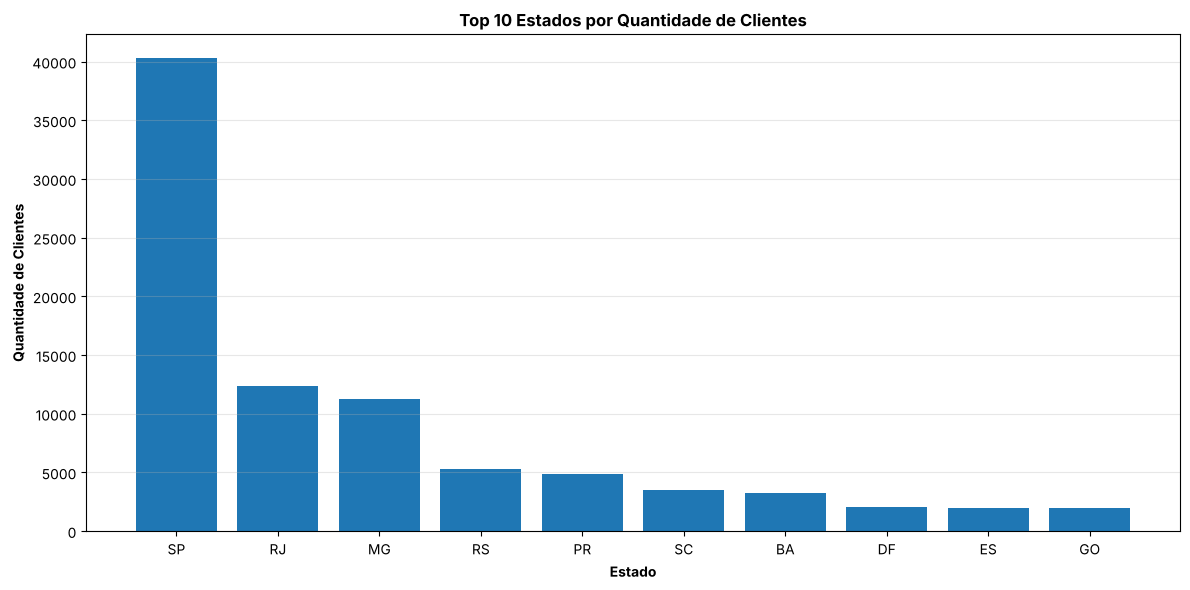

In [92]:
# Top 10 Estados por Quantidade de Clientes

# Selecionar os 10 estados com maior quantidade de clientes
top10_estados = clientes_estado.head(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))

plt.bar(
    top10_estados["Estado"],
    top10_estados["Quantidade_Clientes"]
)

# Título e eixos
plt.title(
    "Top 10 Estados por Quantidade de Clientes",
    fontweight="bold"
)

plt.xlabel(
    "Estado",
    fontweight="bold"
)

plt.ylabel(
    "Quantidade de Clientes",
    fontweight="bold"
)

# Grade
plt.grid(
    axis="y",
    alpha=0.3
)

# Ajustar layout
plt.tight_layout()

# Salvar imagem para o README
plt.savefig(
    "../imagens/clientes_por_estado.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibir gráfico
plt.show()

### Análise da Distribuição de Clientes

A distribuição geográfica dos clientes apresenta forte concentração no estado de São Paulo, que possui mais de 40 mil clientes únicos.

Rio de Janeiro e Minas Gerais aparecem na sequência, com aproximadamente 12,4 mil e 11,3 mil clientes, respectivamente.

Os resultados indicam uma maior presença da plataforma nas regiões Sul e Sudeste, especialmente no mercado paulista.

Essa concentração pode representar tanto a relevância comercial dessas regiões quanto oportunidades de expansão em estados que apresentam menor participação na base de clientes.

### 6.2 Faturamento por Estado

#### Objetivo

Identificar quais estados apresentam maior participação no faturamento da plataforma e comparar o desempenho financeiro com a distribuição geográfica dos clientes.

In [93]:
vendas.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,ano,mes,ano_mes
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,2017,10,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,2018,7,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,2018,8,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,2017,11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,2018,2,2018-02


In [94]:
# Faturamento por Pedido 

pagamento_por_pedido = (
    pagamentos
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

pagamento_por_pedido.head()

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [95]:
vendas_estado = (
    vendas[["order_id", "customer_id"]]
    .merge(
        pagamento_por_pedido,
        on="order_id",
        how="left"
    )
    .merge(
        clientes[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
)

vendas_estado.head()

,order_id,customer_id,payment_value,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,38.71,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,141.46,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,179.12,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,72.20,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,28.62,SP


In [96]:
print("Quantidade de linhas:", len(vendas_estado))
print("Pedidos únicos:", vendas_estado["order_id"].nunique())

print(
    "Pedidos sem pagamento:",
    vendas_estado["payment_value"].isna().sum()
)

print(
    "Pedidos sem estado:",
    vendas_estado["customer_state"].isna().sum()
)

Quantidade de linhas: 99441
Pedidos únicos: 99441
Pedidos sem pagamento: 1
Pedidos sem estado: 0


In [97]:
faturamento_estado = (
    vendas_estado
    .groupby("customer_state", as_index=False)["payment_value"]
    .sum()
)

faturamento_estado.columns = ["Estado", "Faturamento"]

faturamento_estado = (
    faturamento_estado
    .sort_values("Faturamento", ascending=False)
    .reset_index(drop=True)
)

faturamento_estado["Faturamento"] = (
    faturamento_estado["Faturamento"].round(2)
)

faturamento_estado

,Estado,Faturamento
0,SP,"5,998,226.96"
1,RJ,"2,144,379.69"
2,MG,"1,872,257.26"
3,RS,"890,898.54"
4,PR,"811,156.38"
5,SC,"623,086.43"
6,BA,"616,645.82"
7,DF,"355,141.08"
8,GO,"350,092.31"
9,ES,"325,967.55"


In [98]:
faturamento_estado["Percentual_Faturamento"] = (
    faturamento_estado["Faturamento"]
    / faturamento_estado["Faturamento"].sum()
    * 100
).round(2)

faturamento_estado

,Estado,Faturamento,Percentual_Faturamento
0,SP,"5,998,226.96",37.47
1,RJ,"2,144,379.69",13.39
2,MG,"1,872,257.26",11.70
3,RS,"890,898.54",5.57
4,PR,"811,156.38",5.07
5,SC,"623,086.43",3.89
6,BA,"616,645.82",3.85
7,DF,"355,141.08",2.22
8,GO,"350,092.31",2.19
9,ES,"325,967.55",2.04


#### Observação sobre a Qualidade dos Dados

Durante a preparação da análise geográfica foi identificado apenas **1 pedido sem informação de pagamento**, enquanto todos os pedidos possuem identificação do estado do cliente.

Como o registro sem pagamento representa uma parcela mínima da base, ele não compromete de forma relevante os resultados da análise de faturamento por estado.

### 6.3 Comparação entre Clientes, Faturamento e Ticket Médio por Estado

#### Objetivo

Comparar a quantidade de clientes, o faturamento e o ticket médio entre os estados, buscando identificar diferenças no comportamento de consumo e na importância financeira de cada região.

In [99]:
resumo_estado = (
    vendas_estado
    .groupby("customer_state")
    .agg(
        Quantidade_Pedidos=("order_id", "nunique"),
        Faturamento=("payment_value", "sum")
    )
    .reset_index()
)

resumo_estado.columns = [
    "Estado",
    "Quantidade_Pedidos",
    "Faturamento"
]

resumo_estado.head()

,Estado,Quantidade_Pedidos,Faturamento
0,AC,81,"19,680.62"
1,AL,413,"96,962.06"
2,AM,148,"27,966.93"
3,AP,68,"16,262.80"
4,BA,3380,"616,645.82"


In [100]:
# Resumo por Estado 

resumo_estado = resumo_estado.merge(
    clientes_estado[["Estado", "Quantidade_Clientes"]],
    on="Estado",
    how="left"
)

resumo_estado.head()

,Estado,Quantidade_Pedidos,Faturamento,Quantidade_Clientes
0,AC,81,"19,680.62",77
1,AL,413,"96,962.06",401
2,AM,148,"27,966.93",143
3,AP,68,"16,262.80",67
4,BA,3380,"616,645.82",3277


In [101]:
#Ticket Médio

resumo_estado["Ticket_Medio"] = (
    resumo_estado["Faturamento"]
    / resumo_estado["Quantidade_Pedidos"]
).round(2)

resumo_estado["Faturamento"] = (
    resumo_estado["Faturamento"].round(2)
)

resumo_estado = resumo_estado.sort_values(
    "Faturamento",
    ascending=False
).reset_index(drop=True)

resumo_estado

,Estado,Quantidade_Pedidos,Faturamento,Quantidade_Clientes,Ticket_Medio
0,SP,41746,"5,998,226.96",40302,143.68
1,RJ,12852,"2,144,379.69",12384,166.85
2,MG,11635,"1,872,257.26",11259,160.92
3,RS,5466,"890,898.54",5277,162.99
4,PR,5045,"811,156.38",4882,160.78
5,SC,3637,"623,086.43",3534,171.32
6,BA,3380,"616,645.82",3277,182.44
7,DF,2140,"355,141.08",2075,165.95
8,GO,2020,"350,092.31",1952,173.31
9,ES,2033,"325,967.55",1964,160.34


In [102]:
ticket_estado = (
    resumo_estado[
        ["Estado", "Quantidade_Pedidos", "Ticket_Medio"]
    ]
    .sort_values(
        "Ticket_Medio",
        ascending=False
    )
    .reset_index(drop=True)
)

ticket_estado

,Estado,Quantidade_Pedidos,Ticket_Medio
0,PB,536,264.08
1,AC,81,242.97
2,RO,253,240.58
3,AP,68,239.16
4,AL,413,234.77
5,PA,975,223.89
6,TO,280,219.59
7,PI,495,219.24
8,RR,46,218.80
9,SE,350,214.99


#### Análise do Ticket Médio por Estado

A análise demonstra diferenças relevantes no valor médio dos pedidos entre os estados.

A Paraíba (PB) apresenta o maior ticket médio da base, com aproximadamente **R$ 264,08 por pedido**, seguida por Acre (AC), Rondônia (RO) e Amapá (AP).

Por outro lado, São Paulo (SP), apesar de concentrar o maior volume da operação, apresenta ticket médio de aproximadamente **R$ 143,68**, inferior ao observado em diversos estados com menor quantidade de pedidos.

Entretanto, os resultados devem ser interpretados considerando também o volume de transações. Estados com menor quantidade de pedidos podem apresentar tickets médios elevados devido à influência de compras de maior valor.

Dessa forma, o ticket médio deve ser analisado em conjunto com indicadores de volume de pedidos e faturamento.

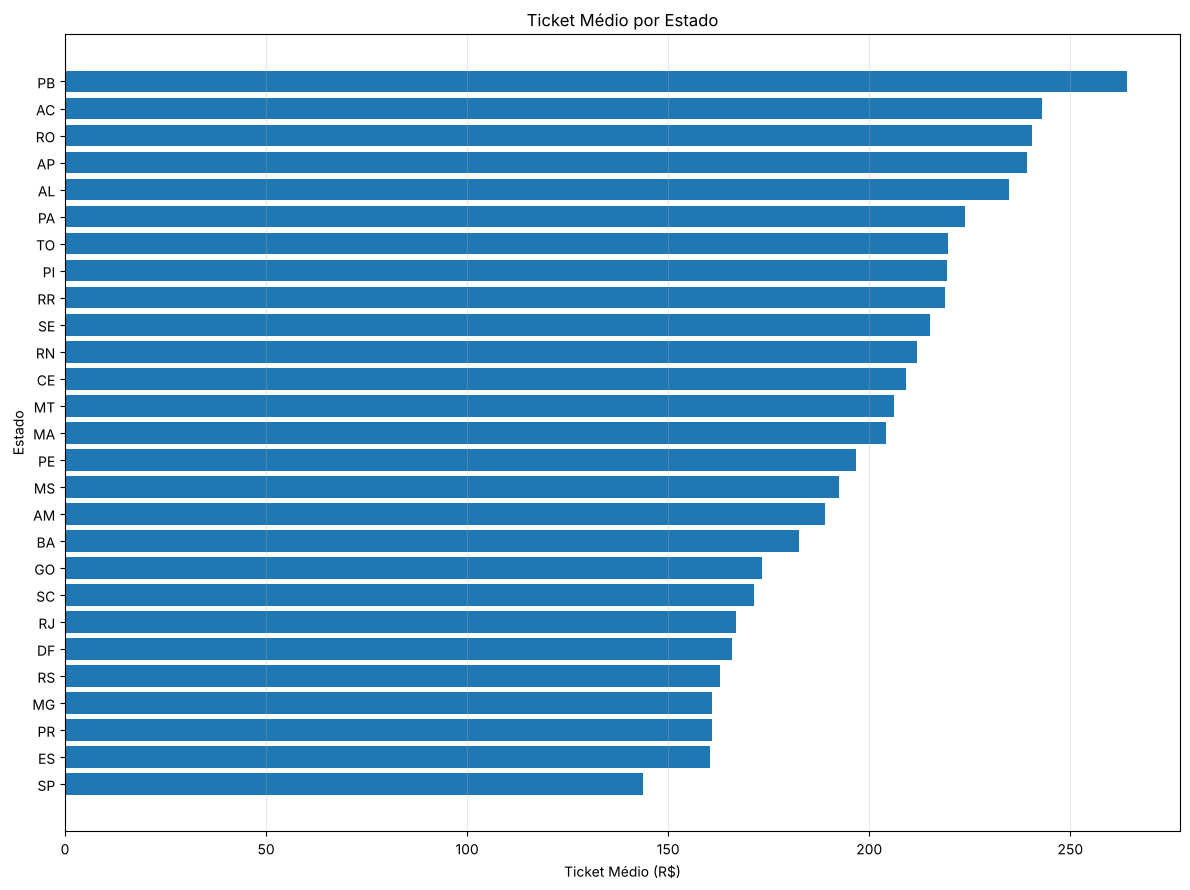

In [103]:
ticket_estado_grafico = ticket_estado.sort_values(
    "Ticket_Medio",
    ascending=True
)

plt.figure(figsize=(12, 9))

plt.barh(
    ticket_estado_grafico["Estado"],
    ticket_estado_grafico["Ticket_Medio"]
)

plt.title("Ticket Médio por Estado")
plt.xlabel("Ticket Médio (R$)")
plt.ylabel("Estado")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Impacto para o Negócio

Os resultados indicam diferentes perfis de consumo entre os estados.

São Paulo representa um mercado de grande escala, concentrando elevado volume de pedidos, embora apresente ticket médio inferior ao de diversos estados.

Já estados como Paraíba, Acre e Rondônia apresentam menor volume de transações, porém valores médios por pedido significativamente maiores.

Essas diferenças podem apoiar estratégias comerciais regionalizadas, permitindo que a empresa desenvolva ações específicas para mercados de alto volume e estratégias distintas para regiões com maior valor médio por transação.

Também é importante considerar o tamanho da amostra de cada estado antes de utilizar o ticket médio isoladamente para decisões estratégicas.

### Conclusão da Análise Geográfica

A análise geográfica revelou uma forte concentração da operação em estados como São Paulo, Rio de Janeiro e Minas Gerais.

Entretanto, a análise do ticket médio mostrou que estados com menor volume de pedidos podem apresentar maior valor médio por transação.

A Paraíba apresentou o maior ticket médio entre os estados analisados, enquanto São Paulo se destacou principalmente pelo elevado volume de pedidos.

Os resultados demonstram que volume, faturamento e ticket médio devem ser analisados conjuntamente para compreender o desempenho regional e apoiar decisões comerciais mais eficientes.

## 7. Análise de Frete e Logística

Nesta etapa será analisado o comportamento logístico do e-commerce, considerando os custos de frete e os prazos de entrega dos pedidos.

### Objetivo

Avaliar o impacto do frete sobre as vendas e analisar o desempenho das entregas, buscando identificar padrões que possam influenciar a experiência do cliente e a eficiência operacional.

In [104]:
print("COLUNAS DA TABELA ITENS:")
print(itens.columns.tolist())

print("\nCOLUNAS DA TABELA PEDIDOS:")
print(pedidos.columns.tolist())

COLUNAS DA TABELA ITENS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

COLUNAS DA TABELA PEDIDOS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


### 7.1 Custo de Frete

#### Objetivo

Analisar os custos de frete associados às vendas, identificando o valor total movimentado em fretes e o custo médio de frete por item vendido.

In [105]:
# Indicadores gerais de frete

frete_total = itens["freight_value"].sum()

frete_medio = itens["freight_value"].mean()

frete_mediano = itens["freight_value"].median()

print(f"Frete total: R$ {frete_total:,.2f}")
print(f"Frete médio por item: R$ {frete_medio:,.2f}")
print(f"Frete mediano por item: R$ {frete_mediano:,.2f}")

Frete total: R$ 2,251,909.54
Frete médio por item: R$ 19.99
Frete mediano por item: R$ 16.26


#### Análise dos Resultados

O custo total de frete movimentado pela plataforma foi de aproximadamente **R$ 2,25 milhões**.

O frete médio por item foi de **R$ 19,99**, enquanto a mediana foi de **R$ 16,26**.

A diferença entre média e mediana indica a existência de pedidos com custos de frete mais elevados, que acabam aumentando o valor médio observado.

Esse comportamento reforça a importância de analisar o impacto do frete sobre o valor dos produtos e identificar possíveis situações em que o custo logístico representa uma parcela significativa da compra.

### 7.2 Participação do Frete no Valor dos Produtos

#### Objetivo

Avaliar o peso dos custos de frete em relação ao valor dos produtos vendidos, permitindo compreender o impacto da logística sobre o valor das vendas.

In [106]:
valor_produtos = itens["price"].sum()
valor_frete = itens["freight_value"].sum()

percentual_frete = (valor_frete / valor_produtos) * 100

print(f"Valor total dos produtos: R$ {valor_produtos:,.2f}")
print(f"Valor total de frete: R$ {valor_frete:,.2f}")
print(f"Participação do frete: {percentual_frete:.2f}%")

Valor total dos produtos: R$ 13,591,643.70
Valor total de frete: R$ 2,251,909.54
Participação do frete: 16.57%


#### Análise dos Resultados

O valor total dos produtos vendidos foi de aproximadamente **R$ 13,59 milhões**, enquanto os custos de frete somaram cerca de **R$ 2,25 milhões**.

O frete representa aproximadamente **16,57% do valor dos produtos vendidos**.

Isso significa que, para cada **R$ 100 em produtos comercializados, aproximadamente R$ 16,57 estão associados ao custo de frete**.

Esse indicador demonstra a relevância dos custos logísticos na operação e reforça a importância de acompanhar estratégias de distribuição, transportadoras e eficiência logística.

### 7.3 Prazo de Entrega

#### Objetivo

Analisar o tempo decorrido entre a realização da compra e a entrega ao cliente, buscando compreender o desempenho logístico da operação.

In [107]:
# Criando base para análise das entregas

entregas = pedidos[
    ["order_id", "order_purchase_timestamp", "order_delivered_customer_date"]
].copy()

# Garantindo que as colunas estejam no formato de data
entregas["order_purchase_timestamp"] = pd.to_datetime(
    entregas["order_purchase_timestamp"]
)

entregas["order_delivered_customer_date"] = pd.to_datetime(
    entregas["order_delivered_customer_date"]
)

# Removendo pedidos sem data de entrega
entregas = entregas.dropna(subset=["order_delivered_customer_date"])

# Calculando o prazo de entrega em dias
entregas["Prazo_Entrega_Dias"] = (
    entregas["order_delivered_customer_date"]
    - entregas["order_purchase_timestamp"]
).dt.total_seconds() / 86400

entregas.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,Prazo_Entrega_Dias
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.44
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,13.78
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9.39
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,13.21
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2.87


In [108]:
print(f"Quantidade de entregas analisadas: {len(entregas):,}")
print(f"Prazo médio de entrega: {entregas['Prazo_Entrega_Dias'].mean():.2f} dias")
print(f"Prazo mediano de entrega: {entregas['Prazo_Entrega_Dias'].median():.2f} dias")
print(f"Menor prazo de entrega: {entregas['Prazo_Entrega_Dias'].min():.2f} dias")
print(f"Maior prazo de entrega: {entregas['Prazo_Entrega_Dias'].max():.2f} dias")

Quantidade de entregas analisadas: 96,476
Prazo médio de entrega: 12.56 dias
Prazo mediano de entrega: 10.22 dias
Menor prazo de entrega: 0.53 dias
Maior prazo de entrega: 209.63 dias


#### Análise dos Resultados

Foram analisadas **96.476 entregas**, com prazo médio de aproximadamente **12,56 dias** e mediana de **10,22 dias**.

A diferença entre média e mediana indica que existem entregas com prazos significativamente elevados, influenciando o prazo médio da operação.

O menor prazo registrado foi de aproximadamente **0,53 dia**, enquanto o maior chegou a **209,63 dias**, indicando a presença de casos extremos que merecem atenção na análise logística.

Esses resultados reforçam a importância de avaliar não apenas o prazo médio, mas também o cumprimento das datas de entrega prometidas aos clientes.

### 7.4 Cumprimento do Prazo de Entrega

#### Objetivo

Avaliar o cumprimento dos prazos prometidos aos clientes, identificando a proporção de pedidos entregues dentro do prazo e com atraso.

In [109]:
analise_prazo = pedidos[
    [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

analise_prazo["order_delivered_customer_date"] = pd.to_datetime(
    analise_prazo["order_delivered_customer_date"]
)

analise_prazo["order_estimated_delivery_date"] = pd.to_datetime(
    analise_prazo["order_estimated_delivery_date"]
)

# Mantendo apenas pedidos que possuem data real de entrega
analise_prazo = analise_prazo.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
)

In [110]:
analise_prazo["Status_Entrega"] = np.where(
    analise_prazo["order_delivered_customer_date"].dt.normalize()
    <= analise_prazo["order_estimated_delivery_date"].dt.normalize(),
    "No Prazo",
    "Atrasada"
)

analise_prazo["Status_Entrega"].value_counts()

Status_Entrega
No Prazo    89941
Atrasada     6535
Name: count, dtype: int64

In [111]:
resumo_prazo = (
    analise_prazo["Status_Entrega"]
    .value_counts()
    .reset_index()
)

resumo_prazo.columns = ["Status", "Quantidade"]

resumo_prazo["Percentual"] = (
    resumo_prazo["Quantidade"]
    / resumo_prazo["Quantidade"].sum()
    * 100
).round(2)

resumo_prazo

,Status,Quantidade,Percentual
0,No Prazo,89941,93.23
1,Atrasada,6535,6.77


#### Análise dos Resultados

A análise do cumprimento dos prazos mostrou que **93,23% das entregas foram realizadas dentro da data estimada**, enquanto **6,77% apresentaram atraso**.

O critério compara apenas a **data** de entrega com a **data** estimada, sem a hora. A data estimada não tem horário (é sempre 00:00), então um pedido entregue no próprio dia previsto é considerado no prazo.

O resultado indica um alto nível de cumprimento dos prazos de entrega pela operação. Entretanto, aproximadamente **7 em cada 100 entregas** ultrapassaram a data prometida ao cliente.

Apesar de representar uma parcela minoritária dos pedidos, os atrasos devem ser acompanhados, pois podem impactar diretamente a experiência do cliente, a satisfação com a compra e os indicadores de qualidade logística.

### 7.5 Análise dos Dias de Atraso

#### Objetivo

Analisar a intensidade dos atrasos nas entregas, identificando quantos dias, em média, os pedidos atrasados ultrapassaram a data estimada de entrega.

In [112]:
# Selecionando apenas entregas atrasadas

atrasos = analise_prazo[
    analise_prazo["Status_Entrega"] == "Atrasada"
].copy()

# Calculando os dias de atraso

atrasos["Dias_Atraso"] = (
    atrasos["order_delivered_customer_date"].dt.normalize()
    - atrasos["order_estimated_delivery_date"].dt.normalize()
).dt.days

print(f"Quantidade de entregas atrasadas: {len(atrasos):,}")
print(f"Atraso médio: {atrasos['Dias_Atraso'].mean():.2f} dias")
print(f"Atraso mediano: {atrasos['Dias_Atraso'].median():.2f} dias")
print(f"Maior atraso: {atrasos['Dias_Atraso'].max():.2f} dias")

Quantidade de entregas atrasadas: 6,535
Atraso médio: 10.62 dias
Atraso mediano: 7.00 dias
Maior atraso: 188.00 dias


#### Análise dos Resultados

Entre as entregas analisadas, **6.535 pedidos foram entregues após a data estimada**.

O atraso médio foi de aproximadamente **10,6 dias**, enquanto a mediana foi de **7 dias**.

A diferença entre média e mediana indica a presença de atrasos extremos, que elevam a média geral. Esse comportamento é reforçado pelo maior atraso identificado, de **188 dias**.

Portanto, embora os atrasos representem apenas **6,77% das entregas**, parte desses casos apresenta desvios relevantes em relação ao prazo prometido, podendo gerar impacto significativo na experiência do cliente.

### 7.6 Distribuição dos Atrasos

#### Objetivo

Classificar as entregas atrasadas de acordo com a quantidade de dias de atraso, permitindo identificar se os problemas logísticos estão concentrados em pequenos atrasos ou em ocorrências mais severas.

In [113]:
atrasos["Faixa_Atraso"] = pd.cut(
    atrasos["Dias_Atraso"],
    bins=[0, 3, 7, 14, 30, float("inf")],
    labels=[
        "Até 3 dias",
        "4 a 7 dias",
        "8 a 14 dias",
        "15 a 30 dias",
        "Acima de 30 dias"
    ]
)

faixas_atraso = (
    atrasos["Faixa_Atraso"]
    .value_counts()
    .sort_index()
    .reset_index()
)

faixas_atraso.columns = [
    "Faixa_Atraso",
    "Quantidade"
]

faixas_atraso

,Faixa_Atraso,Quantidade
0,Até 3 dias,1870
1,4 a 7 dias,1802
2,8 a 14 dias,1479
3,15 a 30 dias,1039
4,Acima de 30 dias,345


In [114]:
faixas_atraso["Percentual"] = (
    faixas_atraso["Quantidade"]
    / faixas_atraso["Quantidade"].sum()
    * 100
).round(2)

faixas_atraso

,Faixa_Atraso,Quantidade,Percentual
0,Até 3 dias,1870,28.62
1,4 a 7 dias,1802,27.57
2,8 a 14 dias,1479,22.63
3,15 a 30 dias,1039,15.90
4,Acima de 30 dias,345,5.28


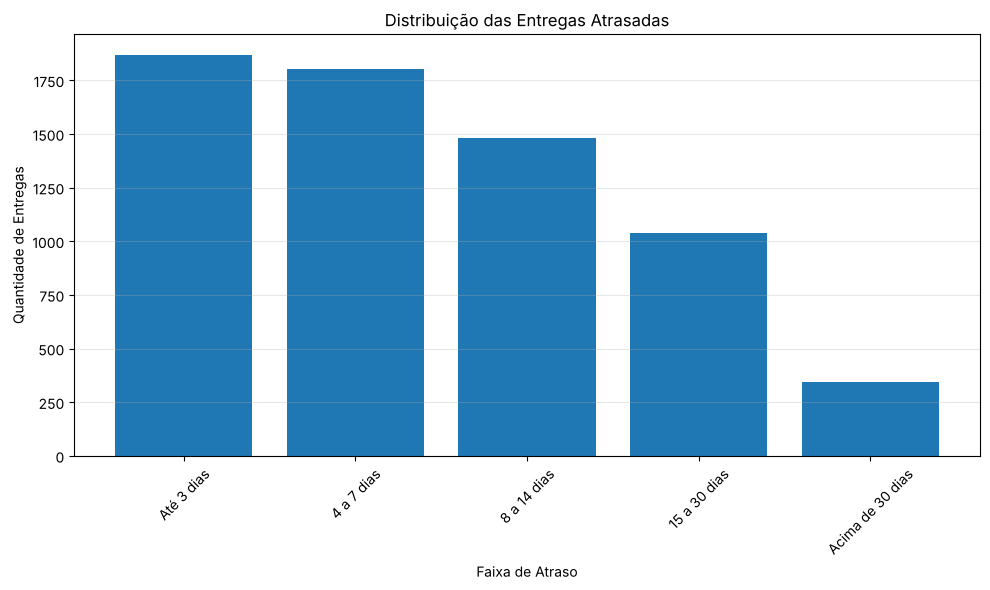

In [115]:
plt.figure(figsize=(10, 6))

plt.bar(
    faixas_atraso["Faixa_Atraso"].astype(str),
    faixas_atraso["Quantidade"]
)

plt.title("Distribuição das Entregas Atrasadas")
plt.xlabel("Faixa de Atraso")
plt.ylabel("Quantidade de Entregas")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Impacto para o Negócio

O acompanhamento das faixas de atraso permite identificar diferentes níveis de criticidade na operação logística.

Atrasos menores podem estar relacionados a variações normais do processo de distribuição, enquanto atrasos mais longos podem indicar problemas relacionados a transportadoras, regiões atendidas, vendedores ou etapas específicas do processo logístico.

A redução dos atrasos mais severos pode contribuir para melhorar a experiência do cliente, reduzir reclamações e aumentar a confiabilidade dos prazos apresentados pela plataforma.

#### Conclusão

A análise logística mostrou que a operação apresenta **93,23% das entregas realizadas dentro do prazo**, demonstrando um elevado nível de cumprimento das datas estimadas.

Entretanto, **6,77% das entregas apresentaram atraso**. Entre esses casos, o atraso médio foi de **10,6 dias** e a mediana de **7 dias**, indicando a presença de ocorrências extremas que elevam a média.

Além disso, o frete representa aproximadamente **16,57% do valor dos produtos vendidos**, evidenciando a relevância dos custos logísticos dentro da operação.

Os resultados indicam que oportunidades de melhoria estão principalmente na redução dos atrasos mais severos e na otimização dos custos de frete, fatores que podem impactar diretamente a experiência do cliente e a eficiência operacional.

## 8. Análise de Satisfação dos Clientes

Nesta etapa será analisada a satisfação dos clientes por meio das avaliações realizadas após as compras.

O objetivo é compreender a distribuição das notas, identificar o nível médio de satisfação dos consumidores e investigar possíveis relações entre a experiência de entrega e avaliações negativas.

### Objetivo

Avaliar o nível de satisfação dos clientes e identificar fatores operacionais que possam estar associados a avaliações mais baixas.

In [116]:
print("Colunas da tabela AVALIAÇÕES:")
print(avaliacoes.columns.tolist())

avaliacoes.head()

Colunas da tabela AVALIAÇÕES:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### 8.1 Distribuição das Avaliações

#### Objetivo

Analisar a distribuição das notas atribuídas pelos clientes, buscando compreender o nível geral de satisfação com as compras realizadas na plataforma.

In [117]:
distribuicao_notas = (
    avaliacoes["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

distribuicao_notas.columns = [
    "Nota",
    "Quantidade"
]

distribuicao_notas

,Nota,Quantidade
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


### 8.2 Indicadores de Satisfação

#### Objetivo

Mensurar o nível geral de satisfação dos clientes por meio da nota média e da participação de avaliações positivas, neutras e negativas.

In [118]:
# Nota média

nota_media = avaliacoes["review_score"].mean()

# Quantidade total de avaliações

total_avaliacoes = avaliacoes["review_score"].count()

# Classificação das avaliações

avaliacoes_positivas = avaliacoes[
    avaliacoes["review_score"] >= 4
]["review_score"].count()

avaliacoes_neutras = avaliacoes[
    avaliacoes["review_score"] == 3
]["review_score"].count()

avaliacoes_negativas = avaliacoes[
    avaliacoes["review_score"] <= 2
]["review_score"].count()

# Percentuais

percentual_positivas = avaliacoes_positivas / total_avaliacoes * 100
percentual_neutras = avaliacoes_neutras / total_avaliacoes * 100
percentual_negativas = avaliacoes_negativas / total_avaliacoes * 100

print(f"Total de avaliações: {total_avaliacoes:,}")
print(f"Nota média: {nota_media:.2f}")
print(f"Avaliações positivas: {percentual_positivas:.2f}%")
print(f"Avaliações neutras: {percentual_neutras:.2f}%")
print(f"Avaliações negativas: {percentual_negativas:.2f}%")

Total de avaliações: 99,224
Nota média: 4.09
Avaliações positivas: 77.07%
Avaliações neutras: 8.24%
Avaliações negativas: 14.69%


#### Análise dos Resultados

A análise das 99.224 avaliações demonstra um elevado nível de satisfação dos clientes, com nota média de **4,09 em uma escala de 1 a 5**.

As avaliações positivas, correspondentes às notas 4 e 5, representam **77,07%** do total, enquanto **8,24%** são avaliações neutras e **14,69%** correspondem a avaliações negativas.

Os resultados indicam que a maioria dos clientes apresenta uma percepção positiva sobre a experiência de compra. Entretanto, a presença de aproximadamente 15% de avaliações negativas representa uma oportunidade de investigação dos fatores que podem estar associados à insatisfação.

### 8.3 Impacto do Atraso na Satisfação dos Clientes

#### Objetivo

Avaliar se atrasos nas entregas estão associados a menores notas de satisfação, comparando as avaliações de pedidos entregues dentro e fora do prazo previsto.

In [119]:
# Selecionando as colunas necessárias

satisfacao_entrega = pedidos[
    [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].merge(
    avaliacoes[
        ["order_id", "review_score"]
    ],
    on="order_id",
    how="inner"
)

# Convertendo datas

satisfacao_entrega["order_delivered_customer_date"] = pd.to_datetime(
    satisfacao_entrega["order_delivered_customer_date"]
)

satisfacao_entrega["order_estimated_delivery_date"] = pd.to_datetime(
    satisfacao_entrega["order_estimated_delivery_date"]
)

# Removendo pedidos sem informação de entrega

satisfacao_entrega = satisfacao_entrega.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

# Classificando a entrega

satisfacao_entrega["Status_Entrega"] = np.where(
    satisfacao_entrega["order_delivered_customer_date"].dt.normalize()
    <= satisfacao_entrega["order_estimated_delivery_date"].dt.normalize(),
    "No Prazo",
    "Atrasada"
)

satisfacao_entrega.head()

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,Status_Entrega
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,4,No Prazo
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,4,No Prazo
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,5,No Prazo
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,5,No Prazo
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,5,No Prazo


In [120]:
#Nota média: No Prazo × Atrasada


satisfacao_status = (
    satisfacao_entrega
    .groupby("Status_Entrega")
    .agg(
        Quantidade_Avaliacoes=("review_score", "count"),
        Nota_Media=("review_score", "mean")
    )
    .reset_index()
)

satisfacao_status["Nota_Media"] = (
    satisfacao_status["Nota_Media"].round(2)
)

satisfacao_status

,Status_Entrega,Quantidade_Avaliacoes,Nota_Media
0,Atrasada,6410,2.27
1,No Prazo,89949,4.29


#### Análise dos Resultados

Os resultados demonstram uma relação relevante entre o cumprimento do prazo de entrega e a satisfação dos clientes.

Pedidos entregues **dentro do prazo** apresentaram nota média de **4,29**, enquanto pedidos **atrasados** registraram nota média de apenas **2,27**.

Isso representa uma redução de aproximadamente **47,1% na nota média** quando ocorre atraso na entrega.

O resultado indica que o desempenho logístico está fortemente associado à experiência do cliente. Dessa forma, reduzir atrasos pode contribuir diretamente para o aumento da satisfação e para uma melhor percepção do serviço oferecido pela plataforma.

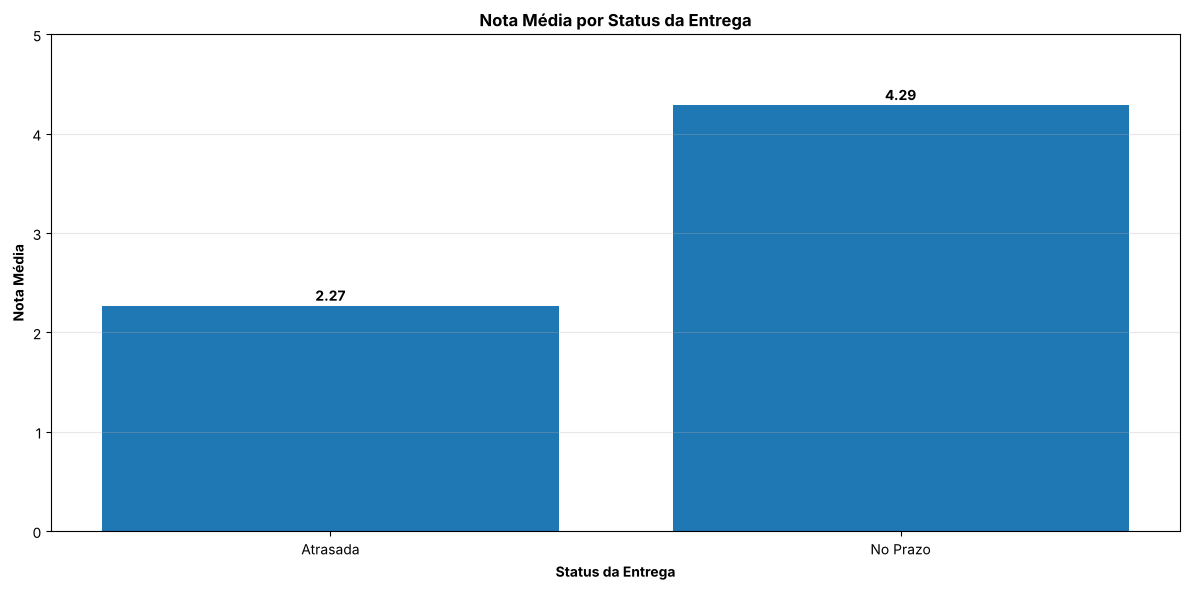

In [121]:
# Nota Média por Status da Entrega

# Criar o gráfico
plt.figure(figsize=(12, 6))

barras = plt.bar(
    satisfacao_status["Status_Entrega"],
    satisfacao_status["Nota_Media"]
)

# Título e eixos
plt.title(
    "Nota Média por Status da Entrega",
    fontweight="bold"
)

plt.xlabel(
    "Status da Entrega",
    fontweight="bold"
)

plt.ylabel(
    "Nota Média",
    fontweight="bold"
)

# Limitar escala das avaliações
plt.ylim(0, 5)

# Exibir os valores acima das barras
for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.05,
        f"{altura:.2f}",
        ha="center",
        fontweight="bold"
    )

# Grade
plt.grid(
    axis="y",
    alpha=0.3
)

# Ajustar layout
plt.tight_layout()

# Salvar imagem para o README
plt.savefig(
    "../imagens/satisfacao_por_entrega.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibir gráfico
plt.show()

### 8.4 Distribuição das Notas por Status da Entrega

#### Objetivo

Analisar como as notas de satisfação estão distribuídas entre pedidos entregues no prazo e pedidos atrasados, buscando identificar se os atrasos estão associados a uma maior concentração de avaliações negativas.

In [122]:
distribuicao_notas_entrega = (
    satisfacao_entrega
    .groupby(["Status_Entrega", "review_score"])
    .size()
    .reset_index(name="Quantidade")
)

distribuicao_notas_entrega

,Status_Entrega,review_score,Quantidade
0,Atrasada,1,3444
1,Atrasada,2,556
2,Atrasada,3,698
3,Atrasada,4,652
4,Atrasada,5,1060
5,No Prazo,1,5965
6,No Prazo,2,2385
7,No Prazo,3,7264
8,No Prazo,4,18335
9,No Prazo,5,56000


In [123]:
distribuicao_notas_entrega["Percentual"] = (
    distribuicao_notas_entrega["Quantidade"]
    / distribuicao_notas_entrega.groupby("Status_Entrega")["Quantidade"].transform("sum")
    * 100
).round(2)

distribuicao_notas_entrega

,Status_Entrega,review_score,Quantidade,Percentual
0,Atrasada,1,3444,53.73
1,Atrasada,2,556,8.67
2,Atrasada,3,698,10.89
3,Atrasada,4,652,10.17
4,Atrasada,5,1060,16.54
5,No Prazo,1,5965,6.63
6,No Prazo,2,2385,2.65
7,No Prazo,3,7264,8.08
8,No Prazo,4,18335,20.38
9,No Prazo,5,56000,62.26


#### Análise dos Resultados

A distribuição das avaliações reforça a associação entre o cumprimento do prazo de entrega e a satisfação dos clientes.

Entre os pedidos **atrasados**, aproximadamente **53,73% receberam nota 1**, enquanto apenas **16,54% receberam nota 5**.

Nos pedidos entregues **dentro do prazo**, o comportamento é praticamente inverso: apenas **6,63% receberam nota 1**, enquanto **62,26% receberam nota máxima (5)**.

Além disso, considerando como avaliações negativas as notas 1 e 2, aproximadamente **62,40% dos pedidos atrasados** receberam avaliações negativas, contra apenas **9,28% dos pedidos entregues no prazo**.

Os resultados indicam uma forte associação entre atrasos logísticos e insatisfação dos clientes, reforçando a importância do cumprimento dos prazos de entrega para a experiência do consumidor.

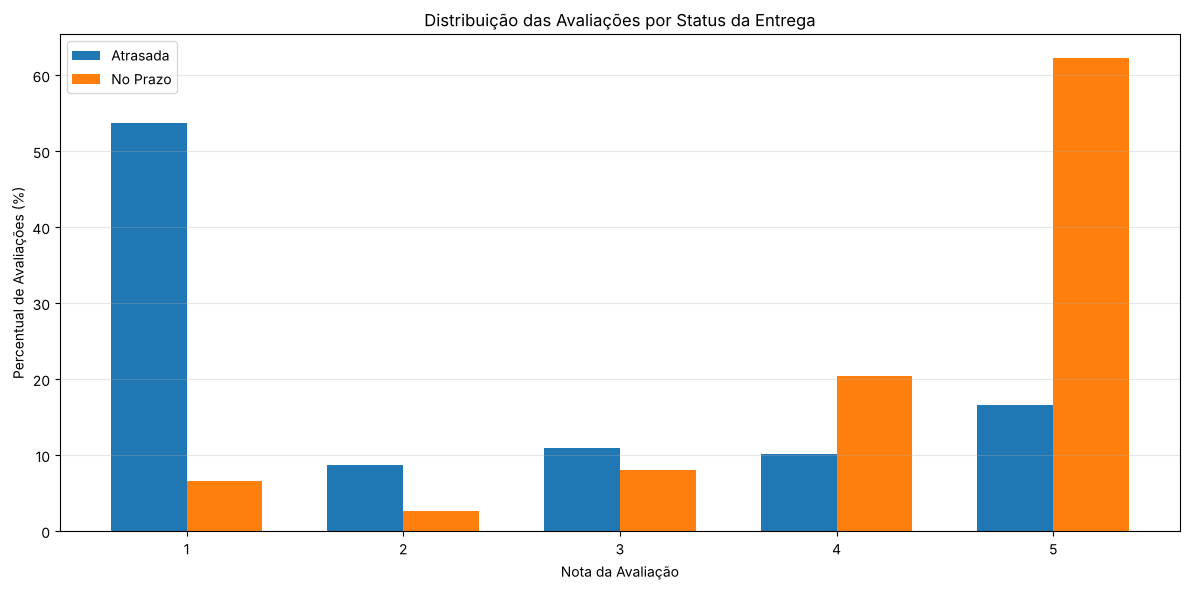

In [124]:
import matplotlib.pyplot as plt

# Separando os dados
atrasadas = distribuicao_notas_entrega[
    distribuicao_notas_entrega["Status_Entrega"] == "Atrasada"
]

no_prazo = distribuicao_notas_entrega[
    distribuicao_notas_entrega["Status_Entrega"] == "No Prazo"
]

# Posição das barras
notas = atrasadas["review_score"]
largura = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    notas - largura/2,
    atrasadas["Percentual"],
    width=largura,
    label="Atrasada"
)

plt.bar(
    notas + largura/2,
    no_prazo["Percentual"],
    width=largura,
    label="No Prazo"
)

plt.title("Distribuição das Avaliações por Status da Entrega")
plt.xlabel("Nota da Avaliação")
plt.ylabel("Percentual de Avaliações (%)")

plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 8.5 Conclusão da Análise de Satisfação dos Clientes

A análise das avaliações revelou um nível geral elevado de satisfação, com **nota média de 4,09** e **77,07% das avaliações classificadas como positivas**.

Entretanto, ao relacionar a satisfação com o desempenho logístico, foi identificada uma diferença relevante entre pedidos entregues dentro e fora do prazo.

Pedidos entregues **no prazo apresentaram nota média de 4,29**, enquanto pedidos **atrasados registraram média de apenas 2,27**, uma redução de aproximadamente **47,1%**.

A distribuição das notas reforça essa associação:

- **53,73% dos pedidos atrasados receberam nota 1**, contra apenas **6,63% dos pedidos entregues no prazo**;
- **62,40% dos pedidos atrasados receberam avaliações negativas (notas 1 ou 2)**;
- entre os pedidos entregues no prazo, apenas **9,28% receberam avaliações negativas**;
- **62,26% dos pedidos entregues no prazo receberam nota máxima (5)**, contra **16,54% dos pedidos atrasados**.

Os resultados demonstram uma forte associação entre o desempenho logístico e a satisfação dos clientes. A redução dos atrasos representa, portanto, uma importante oportunidade para melhorar a experiência do consumidor e os indicadores de satisfação da plataforma.

#### Valor para o Negócio

A análise indica que o prazo de entrega deve ser tratado como um indicador estratégico de experiência do cliente.

Acompanhamento de transportadoras, identificação de regiões com maior incidência de atrasos e monitoramento preventivo de pedidos com risco de descumprimento do prazo podem contribuir para reduzir avaliações negativas e aumentar a satisfação dos consumidores.

## 9. Conclusão Executiva


### Visão Geral

Este projeto teve como objetivo analisar os dados de um e-commerce brasileiro para compreender o desempenho comercial, o comportamento de compra dos clientes, a distribuição geográfica das vendas, os custos logísticos e os fatores associados à satisfação dos consumidores.

A análise permitiu transformar dados transacionais em indicadores de negócio capazes de apoiar decisões nas áreas comercial, logística e de experiência do cliente.

### Principais Indicadores

Ao longo da análise, foram identificados importantes indicadores sobre a operação:

- **Valor total dos produtos vendidos:** R$ 13.591.643,70
- **Valor total de frete:** R$ 2.251.909,54
- **Participação do frete sobre o valor dos produtos:** 16,57%
- **Frete médio por item:** R$ 19,99
- **Prazo médio de entrega:** 12,56 dias
- **Entregas realizadas no prazo:** 93,23%
- **Entregas atrasadas:** 6,77%
- **Atraso médio entre pedidos atrasados:** 10,6 dias
- **Nota média das avaliações:** 4,09
- **Avaliações positivas:** 77,07%
- **Avaliações negativas:** 14,69%

---

### Principais Insights

### 1. Crescimento da operação

A análise temporal demonstrou uma forte expansão da operação ao longo do período analisado.

O faturamento mensal evoluiu de valores inferiores a R$ 200 mil no início de 2017 para patamares próximos ou superiores a **R$ 1 milhão mensais em diversos períodos de 2018**.

Esse comportamento indica crescimento significativo da atividade comercial da plataforma.

### 2. Categorias possuem comportamentos diferentes

A categoria `cama_mesa_banho` apresentou destaque em volume de vendas, enquanto `beleza_saude` apresentou o maior faturamento entre as categorias analisadas.

Esse resultado demonstra que alto volume de vendas não significa necessariamente maior geração de receita, tornando importante analisar conjuntamente quantidade vendida, faturamento e valor médio dos produtos.

### 3. Forte concentração geográfica

São Paulo concentra a maior parcela da base de clientes e pedidos, seguido principalmente por Rio de Janeiro e Minas Gerais.

Entretanto, estados com menor volume de pedidos apresentaram, em alguns casos, tickets médios superiores aos mercados de maior escala.

Isso demonstra a existência de diferentes perfis de consumo entre as regiões brasileiras.

### 4. Frete possui participação relevante na operação

O frete total representou aproximadamente **16,57% do valor dos produtos vendidos**, demonstrando que os custos logísticos possuem participação relevante na experiência econômica das compras realizadas na plataforma.

O acompanhamento do custo de frete por região, categoria e perfil de pedido pode auxiliar na identificação de oportunidades de eficiência logística.

### 5. A maior parte das entregas ocorre dentro do prazo

Das 96.476 entregas analisadas, **93,23% foram realizadas dentro do prazo previsto**, enquanto **6,77% apresentaram atraso**.

Apesar do percentual relativamente baixo de atrasos, os pedidos atrasados apresentaram atraso médio de **10,6 dias**, existindo também casos extremos significativamente superiores.

Entre os pedidos atrasados:

- 28,62% apresentaram atraso de até 3 dias;
- 27,57% apresentaram atraso entre 4 e 7 dias;
- 22,63% apresentaram atraso entre 8 e 14 dias;
- 15,90% apresentaram atraso entre 15 e 30 dias;
- 5,28% apresentaram atraso superior a 30 dias.

### 6. O atraso está fortemente associado à satisfação

Este foi um dos principais insights encontrados no projeto.

Pedidos entregues dentro do prazo apresentaram **nota média de 4,29**, enquanto pedidos atrasados apresentaram média de apenas **2,27**.

Além disso:

- 53,73% dos pedidos atrasados receberam nota 1;
- apenas 6,63% dos pedidos no prazo receberam nota 1;
- 62,26% dos pedidos no prazo receberam nota 5;
- apenas 16,54% dos pedidos atrasados receberam nota 5.

Os dados demonstram uma forte associação entre desempenho logístico e satisfação dos consumidores.

---



### Recomendações para o Negócio

Com base nos resultados encontrados, algumas iniciativas podem contribuir para melhorar o desempenho da operação:

1. **Monitorar pedidos com risco de atraso**, criando indicadores preventivos antes do vencimento do prazo estimado.

2. **Investigar regiões, vendedores e categorias com maior incidência de atrasos**, permitindo identificar gargalos específicos da operação.

3. **Acompanhar conjuntamente logística e satisfação**, utilizando indicadores como percentual de atraso, atraso médio e nota média dos clientes.

4. **Avaliar oportunidades de otimização do frete**, principalmente considerando que o custo logístico representa parcela relevante do valor comercializado.

5. **Explorar categorias de alto faturamento e alto valor médio**, buscando oportunidades de crescimento de receita e estratégias comerciais específicas.

6. **Desenvolver estratégias regionais**, considerando as diferenças entre volume de pedidos, ticket médio e comportamento de consumo entre os estados.

---



### Conclusão

A análise demonstrou que a plataforma apresenta crescimento relevante, elevada concentração de vendas em grandes mercados e desempenho logístico majoritariamente positivo.

Entretanto, os dados também revelaram que os atrasos possuem forte associação com a insatisfação dos consumidores.

Embora apenas uma parcela das entregas apresente atraso, o impacto sobre a experiência do cliente é significativo, com redução expressiva da nota média e aumento da concentração de avaliações negativas.

Dessa forma, iniciativas voltadas à eficiência logística, monitoramento preventivo das entregas e redução dos atrasos representam oportunidades importantes para melhorar simultaneamente a experiência do cliente e a eficiência operacional.

O projeto demonstra como a integração de diferentes fontes de dados pode transformar registros transacionais em informações relevantes para a tomada de decisão orientada por dados.

# 10. Exportação dos Dados Tratados

Após as etapas de preparação, exploração e análise, os principais conjuntos de dados tratados são exportados para arquivos CSV.

Esses arquivos poderão ser utilizados nas próximas etapas do projeto, incluindo análises em SQL e construção do dashboard no Power BI.

In [125]:
vendas_mensais_analise.to_csv(
    "../data/processed/vendas_mensais.csv",
    index=False
)

print("Arquivo vendas_mensais.csv exportado com sucesso!")

Arquivo vendas_mensais.csv exportado com sucesso!


In [126]:
satisfacao_status.to_csv(
    "../data/processed/satisfacao_entrega.csv",
    index=False
)

print("Arquivo satisfacao_entrega.csv exportado com sucesso!")

Arquivo satisfacao_entrega.csv exportado com sucesso!


In [127]:
distribuicao_notas_entrega.to_csv(
    "../data/processed/distribuicao_notas_entrega.csv",
    index=False
)

print("Arquivo distribuicao_notas_entrega.csv exportado com sucesso!")

Arquivo distribuicao_notas_entrega.csv exportado com sucesso!


### 10.1 Exportação dos Principais KPIs

Nesta etapa, os principais indicadores obtidos durante a análise são consolidados e exportados para um arquivo CSV.

O objetivo é disponibilizar uma visão resumida dos resultados do projeto para utilização no README, análises complementares e ferramentas de visualização.

In [128]:
# Cálculo dos principais KPIs do projeto

faturamento_total = pagamentos["payment_value"].sum()

total_pedidos = pedidos["order_id"].nunique()

ticket_medio = faturamento_total / total_pedidos

total_clientes = clientes["customer_unique_id"].nunique()

nota_media = avaliacoes["review_score"].mean()

frete_medio = itens["freight_value"].mean()

# Entregas no prazo
entregas_kpi = pedidos[
    [
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

entregas_kpi["order_delivered_customer_date"] = pd.to_datetime(
    entregas_kpi["order_delivered_customer_date"]
)

entregas_kpi["order_estimated_delivery_date"] = pd.to_datetime(
    entregas_kpi["order_estimated_delivery_date"]
)

entregas_kpi = entregas_kpi.dropna()

percentual_no_prazo = (
    (
        entregas_kpi["order_delivered_customer_date"].dt.normalize()
        <= entregas_kpi["order_estimated_delivery_date"].dt.normalize()
    ).mean()
    * 100
)

# Consolidando os indicadores
resumo_kpis = pd.DataFrame({
    "Indicador": [
        "Faturamento Total",
        "Total de Pedidos",
        "Ticket Médio",
        "Total de Clientes",
        "Nota Média de Satisfação",
        "Frete Médio por Item",
        "Entregas no Prazo"
    ],
    "Valor": [
        round(faturamento_total, 2),
        total_pedidos,
        round(ticket_medio, 2),
        total_clientes,
        round(nota_media, 2),
        round(frete_medio, 2),
        round(percentual_no_prazo, 2)
    ],
    "Unidade": [
        "R$",
        "Pedidos",
        "R$",
        "Clientes",
        "Nota de 1 a 5",
        "R$",
        "%"
    ]
})

resumo_kpis

,Indicador,Valor,Unidade
0,Faturamento Total,"16,008,872.12",R$
1,Total de Pedidos,"99,441.00",Pedidos
2,Ticket Médio,160.99,R$
3,Total de Clientes,"96,096.00",Clientes
4,Nota Média de Satisfação,4.09,Nota de 1 a 5
5,Frete Médio por Item,19.99,R$
6,Entregas no Prazo,93.23,%


In [129]:
# Exportação dos principais KPIs

resumo_kpis.to_csv(
    "../data/processed/resumo_kpis.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo resumo_kpis.csv exportado com sucesso!")

Arquivo resumo_kpis.csv exportado com sucesso!


## 10.2 Validação dos Arquivos Exportados

### Objetivo

Verificar se os arquivos gerados durante o processamento foram exportados corretamente para a pasta `data/processed`, garantindo que os dados estejam disponíveis para as próximas etapas do projeto.

In [130]:
from pathlib import Path

pasta_processed = Path("../data/processed")

arquivos_esperados = [
    "resumo_nulos.csv",
    "vendas_mensais.csv",
    "satisfacao_entrega.csv",
    "distribuicao_notas_entrega.csv",
    "resumo_kpis.csv",
]

for arquivo in arquivos_esperados:
    caminho = pasta_processed / arquivo
    
    if caminho.exists():
        print(f"✅ {arquivo} - OK")
    else:
        print(f"❌ {arquivo} - NÃO ENCONTRADO")

✅ resumo_nulos.csv - OK
✅ vendas_mensais.csv - OK
✅ satisfacao_entrega.csv - OK
✅ distribuicao_notas_entrega.csv - OK
✅ resumo_kpis.csv - OK


## 10.3 Validação Final do Notebook


### Objetivo

Realizar a validação final do notebook, verificando se todas as etapas do projeto podem ser executadas corretamente, desde a importação e preparação dos dados até as análises, visualizações e exportação dos resultados.

Essa validação garante a reprodutibilidade do projeto e identifica possíveis erros relacionados à ordem de execução das células, dependências entre variáveis ou inconsistências no código.

In [131]:
import sqlite3
import pandas as pd
from pathlib import Path

# Caminhos do projeto
pasta_raw = Path("../data/raw")
pasta_processed = Path("../data/processed")

# Criar conexão com o banco SQLite
conexao = sqlite3.connect(pasta_processed / "ecommerce.db")

# Carregar os arquivos CSV
clientes_sql = pd.read_csv(
    pasta_raw / "olist_customers_dataset.csv"
)

pedidos_sql = pd.read_csv(
    pasta_raw / "olist_orders_dataset.csv"
)

itens_sql = pd.read_csv(
    pasta_raw / "olist_order_items_dataset.csv"
)

produtos_sql = pd.read_csv(
    pasta_raw / "olist_products_dataset.csv"
)

pagamentos_sql = pd.read_csv(
    pasta_raw / "olist_order_payments_dataset.csv"
)

avaliacoes_sql = pd.read_csv(
    pasta_raw / "olist_order_reviews_dataset.csv"
)

# Criar as tabelas no banco
clientes_sql.to_sql(
    "olist_customers",
    conexao,
    if_exists="replace",
    index=False
)

pedidos_sql.to_sql(
    "olist_orders",
    conexao,
    if_exists="replace",
    index=False
)

itens_sql.to_sql(
    "olist_order_items",
    conexao,
    if_exists="replace",
    index=False
)

produtos_sql.to_sql(
    "olist_products",
    conexao,
    if_exists="replace",
    index=False
)

pagamentos_sql.to_sql(
    "olist_order_payments",
    conexao,
    if_exists="replace",
    index=False
)

avaliacoes_sql.to_sql(
    "olist_order_reviews",
    conexao,
    if_exists="replace",
    index=False
)

# Finalizar conexão
conexao.close()

print("Banco de dados criado com sucesso.")

Banco de dados criado com sucesso.
